# Joint MCMC Analysis — DIB 15272 / 15672, C2v / Cs
Loads any backend produced by `run_emcee_asym_both.py`, infers all settings
from the filename, redoes the full convergence analysis, makes the corner plot,
and draws 10 posterior-sample profile overlays.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import corner, h5py, os, glob, re, io, subprocess, tempfile
import emcee
from scipy.stats import gaussian_kde, ks_2samp
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from IPython.display import display, Image
import warnings
import os.path as osp
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys
sys.path.insert(0, os.path.expanduser('~/DIB'))
from MCMC_convergence_tests import detect_multimodal, ks_stability_test, compute_rhat, format_diagnostics

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=11, direction='in', top=True)
plt.rc('ytick', labelsize=11, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=10)
import datetime
import pandas as pd
from scipy.stats import chi2 as chi2_dist


In [101]:
backend_dir =  osp.expanduser("~/../../scratch/gpfs/MELCHIOR/cj1223/DIB")  # <- replace with your emcee backend file
files = [f for f in os.listdir(backend_dir) if 'SymmetryCs' in f and '_sweep_Andrew' in f and '.h5' in f]
files = [f for f in files if '15672' not in f]
files

['15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep_Andrew.h5',
 '15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc0_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5',
 '15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errDefault_trunc0_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5',
 '15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errPlate_trunc0_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5',
 '15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errPlate_trunc10_balanceErrFalse_

## 1  User Configuration

In [102]:
# ════════════════════════════════════════════════════════════════════════════
#  FILE SELECTION
#   Set file_override = '/full/path/to/backend.h5' to pin a specific file.
#   Otherwise the script lists all matching files and picks file_index.
# ════════════════════════════════════════════════════════════════════════════
dib_band       = '15272'   # '15272' or '15672'
symmetry_group = 'Cs'    # 'C2v'  or 'Cs'
file_index     = 0      # which matching file to load (0 = most recently modified)
file_override  = None      # str path or None
# file_override = backend_dir + '/' + '15272_run_DIB15272_SymmetryC2v_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTFalse_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errDefault_trunc0_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5'
# ════════════════════════════════════════════════════════════════════════════
#  ANALYSIS OPTIONS
# ════════════════════════════════════════════════════════════════════════════
save_fig           = True  # also save figures to disk as PDF next to the backend
n_samples          = 25     # random posterior draws for profile plots
rerun_coefficients = False  # True → recompute linear scalars; False → use stored blobs

# Convergence thresholds
PRIMARY_TAU_MULT = 40   # primary:  N > P * max(tau)
SOFT_TAU_MULT    = 30   # soft:     >= half of params past S * tau
BURNIN_TAU_MULT  = 5    # burn-in:  discard first B * max(tau) steps

SCRATCH_DIR = os.path.expanduser('~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/')

def find_backend_files(scratch_dir, dib, sym):
    all_h5 = glob.glob(os.path.join(scratch_dir, '*.h5'))
    matching = [
        f for f in all_h5
        if f'{dib}_run_' in os.path.basename(f)
        and f'Symmetry{sym}' in os.path.basename(f)
    ]
    return sorted(matching, key=os.path.getmtime, reverse=True)  # newest first

def find_backend_files(scratch_dir, dib, sym):
    all_h5 = glob.glob(os.path.join(scratch_dir, '*.h5'))
    matching = [
        f for f in all_h5
        if f'{dib}' in os.path.basename(f)
        and f'Symmetry{sym}' in os.path.basename(f)
    ]
    return sorted(matching, key=os.path.getmtime, reverse=True)  # newest first

if file_override is not None:
    selected_file = file_override
    print(f'Using override: {selected_file}')
else:
    candidates = find_backend_files(SCRATCH_DIR, dib_band, symmetry_group)
    if not candidates:
        raise FileNotFoundError(
            f'No backend files found for DIB {dib_band}, symmetry {symmetry_group}\n'
            f'Searched in: {SCRATCH_DIR}')
    print(f'Found {len(candidates)} matching file(s) — sorted newest first:')
    for i, f in enumerate(candidates):
        marker = '  <-- selected' if i == file_index else ''
        print(f'  [{i}]  {os.path.basename(f)}{marker}')
    selected_file = candidates[file_index]

print(f'\nSelected:\n  {selected_file}')

# ── Figure output directory ────────────────────────────────────────────────────
DATE = datetime.datetime.now().strftime('%Y%m%d')
FIG_DIR = os.path.join(selected_file[:-3], '_figures_'+DATE)
if save_fig:
    os.makedirs(FIG_DIR, exist_ok=True)
    print(f'Figures directory: {FIG_DIR}')


Found 17 matching file(s) — sorted newest first:
  [0]  15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc0_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5  <-- selected
  [1]  15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc0_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep_Andrew.h5
  [2]  15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenterNone_centeroffset0p01_sweep_Andrew.h5
  [3]  15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p05_errPlate_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep_Andrew.h5
  [4]  15272_run_DIB15272_SymmetryCs_BCFalse_F1p0_DTrue_FlatFalse_SpecTru

## Notes

### 15672 C2v

- Amazing fit to direct, less ideal fit to DT (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p15_errPlate_trunc10_balanceErrFalse_dTcenterNone_centeroffset0p1_sweep.h5```), high Temp (~20)
- Very bad fit to direct, insanely good fit to DT (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc10_balanceErrTrue_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5```), low Temp (~9 K)

- No great fit to direct, good fit to DT (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5```), low Temp (~9 K)
- Bad fit to direct, quite good fit to DT (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p15_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5```), low Temp (~7 K)

- Decent fit to direct, 50% good fit to DT (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p1_sweep.h5```), low Temp (~8 K)

- Failed run (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5```)

- Very nice, not perfect, for both  (```15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5```), low Temp (~8.5 K)

### 15672 Cs

- Not great (```15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p15_errDefault_trunc10_balanceErrFalse_dTcenterNone_centeroffset0p1_sweep.h5```)
- Amazing on both (```15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc0_balanceErrFalse_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5```)

### 15272

- 

## 3  Parse Filename Metadata

In [98]:
fname = os.path.basename(selected_file)

inferred_dib      = '15672' if '15672' in fname else '15272'
inferred_sym      = 'C2v'   if 'SymmetryC2v' in fname else 'Cs'
B_not_equal_C     = 'BCTrue'  in fname
use_direct        = 'DTrue'   in fname
use_plate_errs    = 'errPlate' in fname
use_old_errs      = 'errOld'   in fname
use_scalar_prior  = 'nonlinFalse' in fname  # nonlin=False → scalar prior path used

# Center offset: 'centeroffsetFalse' = no offset; any float string = fitted
co_match = re.search(r'centeroffset([^_]+)', fname)
has_center_offset = bool(co_match) and co_match.group(1) != 'False'

trunc_match = re.search(r'trunc(\d+)', fname)
extra_trunc = int(trunc_match.group(1)) if trunc_match else 0

fudge_match = re.search(r'_F([0-9p]+)_', fname)
fudge = float(fudge_match.group(1).replace('p', '.')) if fudge_match else 5.0

balance_errs     = 'balanceErrTrue'  in fname
emphasize_center = 'dTcenterNone' not in fname

c_crop = (10 if use_direct and not use_old_errs else 30) + extra_trunc
gf_sigma = 0.01

print('Inferred settings from filename:')
print(f'  DIB band:       {inferred_dib}')
print(f'  Symmetry:       {inferred_sym}')
print(f'  B ≠ C:          {B_not_equal_C}')
print(f'  Center offset:  {has_center_offset}')
print(f'  Use direct:     {use_direct}')
print(f'  Plate errors:   {use_plate_errs}')
print(f'  Old errors:     {use_old_errs}')
print(f'  Fudge factor:   {fudge}')
print(f'  Extra trunc:    {extra_trunc}  (edge crop c = {c_crop})')
print(f'  Balance errors: {balance_errs}')

Inferred settings from filename:
  DIB band:       15272
  Symmetry:       C2v
  B ≠ C:          False
  Center offset:  True
  Use direct:     True
  Plate errors:   False
  Old errors:     False
  Fudge factor:   1.0
  Extra trunc:    0  (edge crop c = 10)
  Balance errors: False


## 4  Load Chain from Backend

In [100]:
backend  = emcee.backends.HDFBackend(selected_file, read_only=True)
chain    = backend.get_chain()     # (nsteps, nwalkers, ndim)
log_prob = backend.get_log_prob()  # (nsteps, nwalkers)

try:
    raw_blobs = backend.get_blobs()
    # Normalise to float array (nsteps, nwalkers, n_blobs)
    if raw_blobs is not None and raw_blobs.dtype.names is not None:
        blobs = np.column_stack([raw_blobs[n].reshape(raw_blobs.shape[0], raw_blobs.shape[1], -1)
                                  for n in raw_blobs.dtype.names])
    else:
        blobs = raw_blobs
    blobs = blobs.astype(float)
    n_blobs = blobs.shape[-1]
except Exception as e:
    print(f'No blobs available ({e})')
    blobs = None
    n_blobs = 0

nsteps, nwalkers, ndim = chain.shape

# ── Derive settings from ndim as cross-check ─────────────────────────────────
def infer_from_ndim(ndim, sym):
    if ndim == 6:  return False, False
    if ndim == 7:  return False, True
    if ndim == 8:  return True,  False
    if ndim == 9:  return True,  True
    return None, None

bnc_from_ndim, co_from_ndim = infer_from_ndim(ndim, inferred_sym)
if bnc_from_ndim != B_not_equal_C:
    print(f'⚠  B_not_equal_C from filename ({B_not_equal_C}) differs from ndim ({ndim}). Using ndim.')
    B_not_equal_C = bnc_from_ndim
if co_from_ndim != has_center_offset:
    print(f'⚠  has_center_offset from filename ({has_center_offset}) differs from ndim ({ndim}). Using ndim.')
    has_center_offset = co_from_ndim

# ── Parameter labels ─────────────────────────────────────────────────────────
if B_not_equal_C:
    labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]',
              r'$\alpha_A$', r'$\alpha_B$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
else:
    if inferred_sym == 'Cs':
        labels = ['T [K]', 'A [cm⁻¹]', 'BC [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_{BC}$', r'$\tau$ [cm⁻¹]']
    else:  # C2v B=A
        labels = ['T [K]', 'A [cm⁻¹]', 'C [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
if has_center_offset:
    labels.append(r'$\delta_{cen}$ [cm⁻¹]')

print(f'Chain shape:     {chain.shape}')
print(f'Log-prob shape:  {log_prob.shape}')
print(f'Blobs shape:     {blobs.shape if blobs is not None else "N/A"}')
print(f'ndim = {ndim},  labels = {labels}')

Chain shape:     (12, 64, 7)
Log-prob shape:  (12, 64)
Blobs shape:     (12, 64, 6)
ndim = 7,  labels = ['T [K]', 'A [cm⁻¹]', 'C [cm⁻¹]', '$\\alpha_A$', '$\\alpha_C$', '$\\tau$ [cm⁻¹]', '$\\delta_{cen}$ [cm⁻¹]']


## 5  Load Data

In [42]:
DATA_FILE_MAP  = {'15272': os.path.expanduser('~/DIB/all_errs/res_dib_15272.h5'),
                  '15672': os.path.expanduser('~/DIB/all_errs/res_dib_15672.h5')}
PLATE_ERR_MAP  = {'15272': os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5'),
                  '15672': os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')}
LSF_MAP        = {'15272': os.path.expanduser('~/DIB/LSFs/lsf_15272.h5'),
                  '15672': os.path.expanduser('~/DIB/LSFs/lsf_15672.h5')}

with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as dib_f:
    data_wavelength = dib_f['wav'][:]
    data_flux       = dib_f['mean'][:, 0]
    data_flux_dT    = dib_f['mean'][:, 1]
    _noise_std      = np.sqrt(dib_f['var'][:, 0])
    _noise_std_dT   = np.sqrt(dib_f['var'][:, 1])

if use_plate_errs:
    with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
        data_flux     = pf['mean'][:, 0]
        data_flux_dT  = pf['mean'][:, 1]
        _noise_std    = np.sqrt(pf['var'][:, 0])
        _noise_std_dT = np.sqrt(pf['var'][:, 1])
elif use_old_errs:
    with h5py.File(os.path.expanduser('~/DIB/all_errs/jackknife_dib.h5'), 'r') as ef:
        import pandas as pd
        meas = pd.read_csv(os.path.expanduser('~/DIB/all_errs/pca_version.txt'),
                           sep=r'\s+', names=['wavelength','PC1_1','PC1_2','PC2_1','PC2_2'])
        data_wavelength = meas['wavelength'].values
        data_flux       = ef['mean'][0, :, 0]
        data_flux_dT    = ef['mean'][0, :, 1]
        _noise_std      = np.sqrt(ef['var'][:, 0])
        _noise_std_dT   = np.sqrt(ef['var'][:, 1])

noise_std    = fudge * _noise_std
noise_std_dT = fudge * _noise_std_dT

if balance_errs:
    peak_range   = np.abs(np.nanmax(data_flux)    - np.nanmin(data_flux))
    dT_range     = np.abs(np.nanmax(data_flux_dT) - np.nanmin(data_flux_dT))
    peak_rel_err = np.nanmedian(noise_std)    / peak_range
    dT_rel_err   = np.nanmedian(noise_std_dT) / dT_range
    noise_std    = noise_std * (dT_rel_err / peak_rel_err)

with h5py.File(LSF_MAP[inferred_dib], 'r') as lf:
    wav_lsf = lf['wav'][:]

print(f'Data wavelength range: {data_wavelength[0]:.2f} – {data_wavelength[-1]:.2f} Å  ({len(data_wavelength)} pixels)')
print(f'Fit range (after c={c_crop} crop): {data_wavelength[c_crop]:.2f} – {data_wavelength[-c_crop-1]:.2f} Å')

Data wavelength range: 15262.09 – 15281.92 Å  (95 pixels)
Fit range (after c=10 crop): 15264.20 – 15279.81 Å


## 6  Convergence Analysis

In [43]:
# ── Autocorrelation time ──────────────────────────────────────────────────────
tau = emcee.autocorr.integrated_time(chain, tol=0)
ess = nsteps / tau

# Acceptance fraction (stored in backend as accepted step count)
try:
    af = backend.accepted / nsteps
except Exception:
    af = np.full(nwalkers, np.nan)

# Stuck walkers
var_last = np.var(chain[-100:], axis=0)   # (nwalkers, ndim)
stuck = (af < 0.025) | (var_last.mean(axis=1) < 1e-10)

# R-hat and KS on second-half flat samples
flat_half = chain[nsteps // 2:].reshape(-1, ndim)
rhat       = compute_rhat(chain)
ks_chunks, ks_tail = ks_stability_test(chain, flat_half, tau=int(np.mean(tau)))

# Multimodality
multimodal_peaks = np.array([detect_multimodal(flat_half[:, i]) for i in range(ndim)])

# ── Convergence verdicts ─────────────────────────────────────────────────────
converged_primary      = nsteps > PRIMARY_TAU_MULT * tau
converged_soft_per_par = nsteps > SOFT_TAU_MULT    * tau
n_soft_pass            = np.sum(converged_soft_per_par)
converged_soft         = n_soft_pass >= ndim // 2

print('=' * 70)
print(f'  N = {nsteps} steps,  {nwalkers} walkers,  {ndim} parameters')
print(f'  Acceptance fraction (mean) = {af.mean():.3f}  (ideal 0.2–0.5)')
print(f'  Stuck walkers: {np.sum(stuck)}')
print('=' * 70)
print(f'{"Parameter":<22} {"tau":>8} {"N/tau":>8} {f">{PRIMARY_TAU_MULT}*tau":>10} {f">{SOFT_TAU_MULT}*tau":>10}')
print('-' * 70)
for i, lbl in enumerate(labels):
    p_pass = '✓' if converged_primary[i]      else '✗'
    s_pass = '✓' if converged_soft_per_par[i] else '✗'
    print(f'{lbl:<22} {tau[i]:>8.1f} {nsteps/tau[i]:>8.1f}   {p_pass:^9}   {s_pass:^9}')
print('=' * 70)
if np.all(converged_primary):
    print('\n✓✓  FULLY CONVERGED  (all parameters pass N > 50 tau)')
elif converged_soft:
    print(f'\n~   SOMEWHAT CONVERGED  ({n_soft_pass}/{ndim} parameters past {SOFT_TAU_MULT} tau)')
else:
    print(f'\n✗   NOT YET CONVERGED  ({n_soft_pass}/{ndim} parameters past {SOFT_TAU_MULT} tau)')

  N = 11100 steps,  64 walkers,  9 parameters
  Acceptance fraction (mean) = 0.319  (ideal 0.2–0.5)
  Stuck walkers: 2
Parameter                   tau    N/tau    >40*tau    >30*tau
----------------------------------------------------------------------
T [K]                     520.5     21.3       ✗           ✗    
A [cm⁻¹]                  667.2     16.6       ✗           ✗    
B [cm⁻¹]                  691.4     16.1       ✗           ✗    
C [cm⁻¹]                  680.0     16.3       ✗           ✗    
$\alpha_A$                646.9     17.2       ✗           ✗    
$\alpha_B$                375.9     29.5       ✗           ✗    
$\alpha_C$                182.4     60.9       ✓           ✓    
$\tau$ [cm⁻¹]              55.0    201.9       ✓           ✓    
$\delta_{cen}$ [cm⁻¹]     275.2     40.3       ✓           ✓    

✗   NOT YET CONVERGED  (3/9 parameters past 30 tau)


## 7  Stored Diagnostic String (last checkpoint)

In [44]:
with h5py.File(selected_file, 'r') as f:
    fig_groups = sorted(
        [k for k in f.keys() if k.startswith('figures_')],
        key=lambda x: int(x.split('_')[1]))

print(f'Stored diagnostic checkpoints: {[int(g.split("_")[1]) for g in fig_groups]}')

with h5py.File(selected_file, 'r') as f:
    if fig_groups:
        last_grp = fig_groups[-1]
        if 'diagnostics' in f[last_grp]:
            diag_str = f[last_grp]['diagnostics'][()].decode('utf-8')
            print(diag_str)
        else:
            print('(no diagnostics stored in last group)')

Stored diagnostic checkpoints: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 440, 460, 480, 500, 520, 540, 560, 580, 600, 620, 640, 660, 680, 700, 720, 740, 760, 780, 800, 820, 840, 860, 880, 900, 920, 940, 960, 980, 1000, 1020, 1040, 1060, 1080, 1100, 1120, 1140, 1160, 1180, 1200, 1220, 1240, 1260, 1280, 1300, 1320, 1340, 1360, 1380, 1400, 1420, 1440, 1460, 1480, 1500, 1520, 1540, 1560, 1580, 1600, 1620, 1640, 1660, 1680, 1700, 1720, 1740, 1760, 1780, 1800, 1820, 1840, 1860, 1880, 1900, 1920, 1940, 1960, 1980, 2000, 2020, 2040, 2060, 2080, 2100, 2120, 2140, 2160, 2180, 2200, 2220, 2240, 2260, 2280, 2300, 2320, 2340, 2360, 2380, 2400, 2420, 2440, 2460, 2480, 2500, 2520, 2540, 2560, 2580, 2600, 2620, 2640, 2660, 2680, 2700, 2720, 2740, 2760, 2780, 2800, 2820, 2840, 2860, 2880, 2900, 2920, 2940, 2960, 2980, 3000, 3020, 3040, 3060, 3080, 3100, 3120, 3140, 3160, 3180, 3200, 3220, 3240, 3260, 3280, 3300, 3320, 3340, 3360, 3380, 3400, 3

## 8  Tau History

Tau history: 554 checkpoints (554 from stored strings, 0 recomputed)


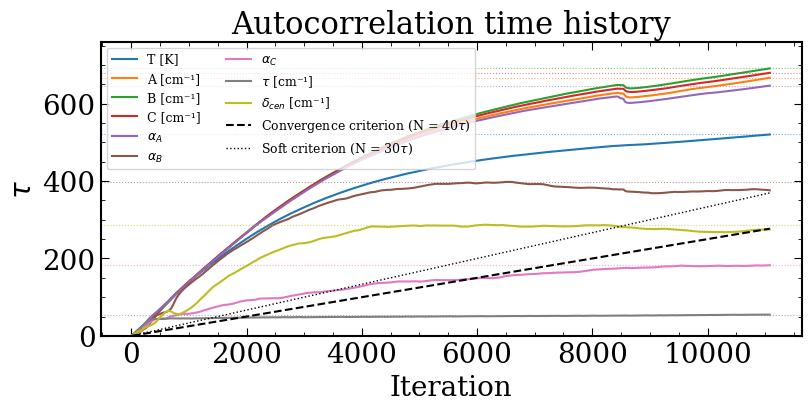

In [45]:
# ── Try to parse tau from stored diagnostic strings first ────────────────────
# Format in stored string: 'Autocorrelation time (tau)         : [v1 v2 ...]'
_tau_re = re.compile(r'Autocorrelation time \(tau\)\s*:\s*\[([^\]]+)\]')

iter_hist = []
tau_hist  = []
missing   = []   # checkpoints where parsing failed — will recompute these

with h5py.File(selected_file, 'r') as f:
    for grp_name in fig_groups:
        n = int(grp_name.split('_')[1])
        parsed = False
        if 'diagnostics' in f[grp_name]:
            diag = f[grp_name]['diagnostics'][()].decode('utf-8')
            m = _tau_re.search(diag)
            if m:
                try:
                    t = np.array([float(x) for x in m.group(1).split()])
                    if len(t) == ndim:
                        iter_hist.append(n)
                        tau_hist.append(t)
                        parsed = True
                except ValueError:
                    pass
        if not parsed:
            missing.append(n)

# Fall back to recomputing only for checkpoints where parsing failed
if missing:
    print(f'Recomputing tau for {len(missing)} checkpoint(s) where stored string was missing/malformed...')
    for n in missing:
        try:
            t = emcee.autocorr.integrated_time(chain[:n], tol=0)
        except Exception:
            t = np.full(ndim, np.nan)
        iter_hist.append(n)
        tau_hist.append(t)

# Sort by iteration
order     = np.argsort(iter_hist)
iter_hist = np.array(iter_hist)[order]
tau_hist  = np.array(tau_hist)[order]   # (n_checkpoints, ndim)

print(f'Tau history: {len(iter_hist)} checkpoints '
      f'({len(iter_hist)-len(missing)} from stored strings, {len(missing)} recomputed)')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(ndim):
    col = colors[i % len(colors)]
    ax.plot(iter_hist, tau_hist[:, i], label=labels[i], color=col)
    ax.axhline(np.nanmax(tau_hist[:, i]), color=col, ls=':', lw=0.8, alpha=0.6)

ax.plot(iter_hist, iter_hist / PRIMARY_TAU_MULT, 'k--', lw=1.5,
        label=f'Convergence criterion (N = {PRIMARY_TAU_MULT}' + r'$\tau$)')
ax.plot(iter_hist, iter_hist / SOFT_TAU_MULT, 'k:', lw=1,
        label=f'Soft criterion (N = {SOFT_TAU_MULT}' + r'$\tau$)')

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\tau$')
ax.set_title('Autocorrelation time history')
finite_max = np.nanmax(tau_hist)
if np.isfinite(finite_max):
    ax.set_ylim(0, finite_max * 1.10)
ax.legend(fontsize=9, ncol=2)

if save_fig:
    fig.savefig(os.path.join(FIG_DIR, f'tau_history.pdf'), bbox_inches='tight')
plt.show()

## 9  Walker Traces

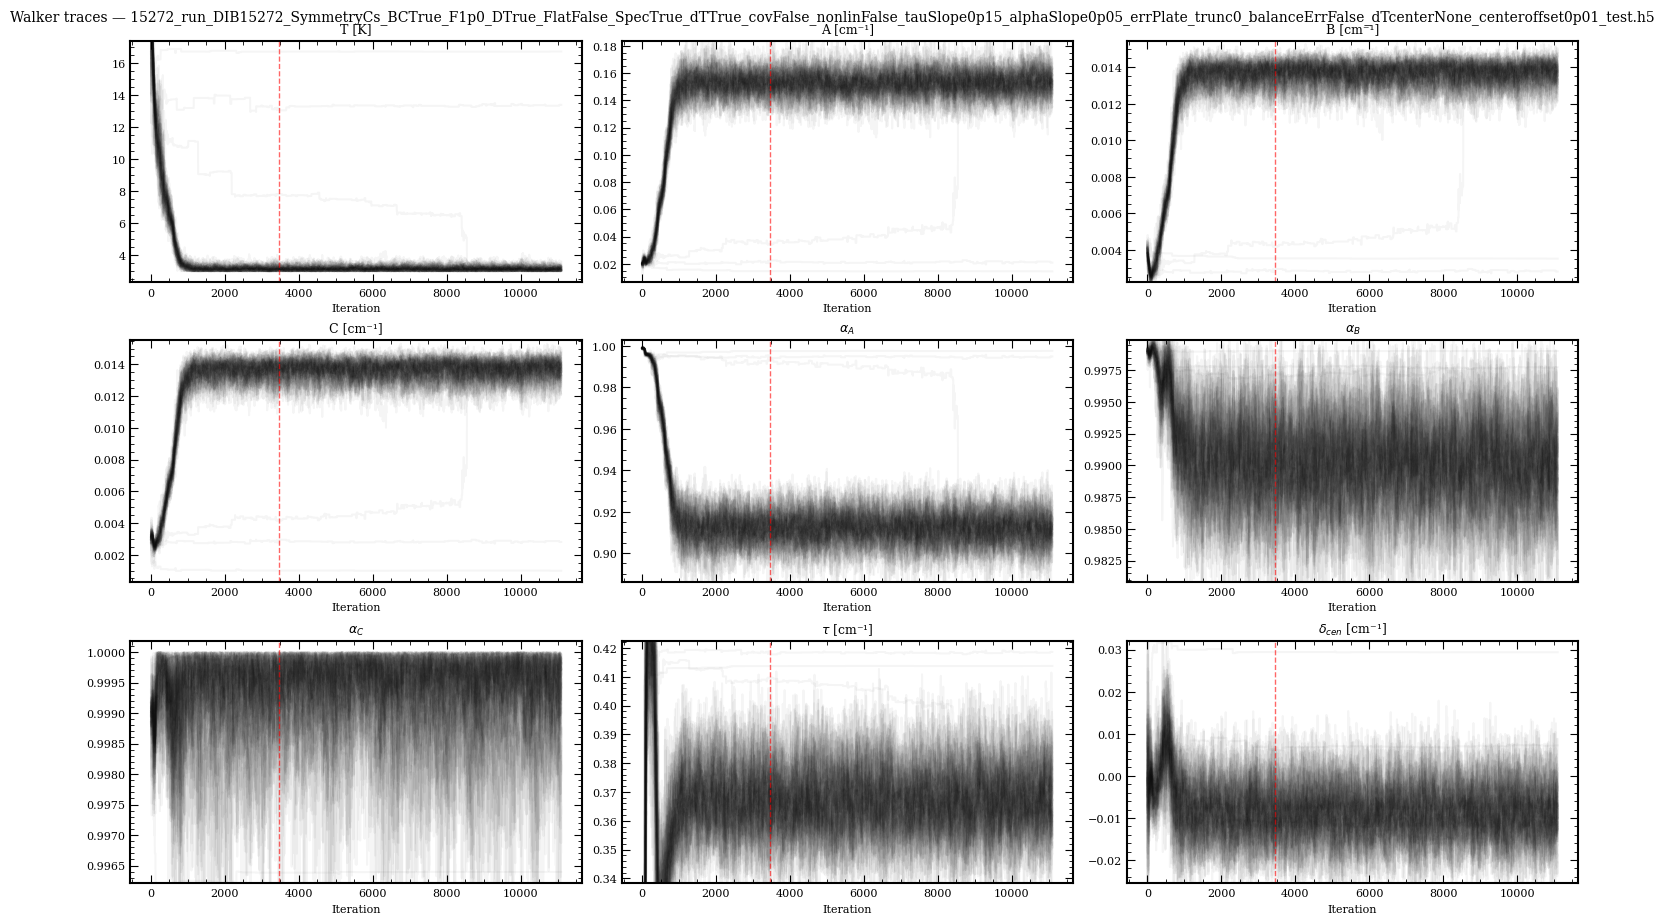

In [46]:
from MCMC_convergence_tests import layouts

nrows, ncols = layouts[ndim]
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), constrained_layout=True)
axs = np.array(axs).reshape(nrows, ncols)
fig.suptitle(f'Walker traces — {os.path.basename(selected_file)}', fontsize=10, y=1.01)

for idx in range(ndim):
    r, c = divmod(idx, ncols)
    ax   = axs[r, c]
    ax.plot(chain[:, :, idx], 'k', alpha=max(0.02, 0.3/np.sqrt(nwalkers)), rasterized=True)
    ax.set_title(labels[idx], fontsize=9)
    ax.set_xlabel('Iteration', fontsize=8)
    ax.tick_params(labelsize=8)
    lo, hi = np.percentile(chain[-min(1000,nsteps):, :, idx], [0.5, 99.5])
    ax.set_ylim(lo - 0.05*(hi-lo), hi + 0.05*(hi-lo))
    # Mark burn-in
    burnin_line = int(BURNIN_TAU_MULT * np.max(tau))
    ax.axvline(burnin_line, color='red', lw=1, ls='--', alpha=0.6)

for idx in range(ndim, nrows*ncols):
    r, c = divmod(idx, ncols)
    axs[r, c].set_visible(False)

if save_fig:
    fig.savefig(os.path.join(FIG_DIR, f'traces.pdf'), bbox_inches='tight')
plt.show()

## 10  Posterior Stability (KS Chunks)

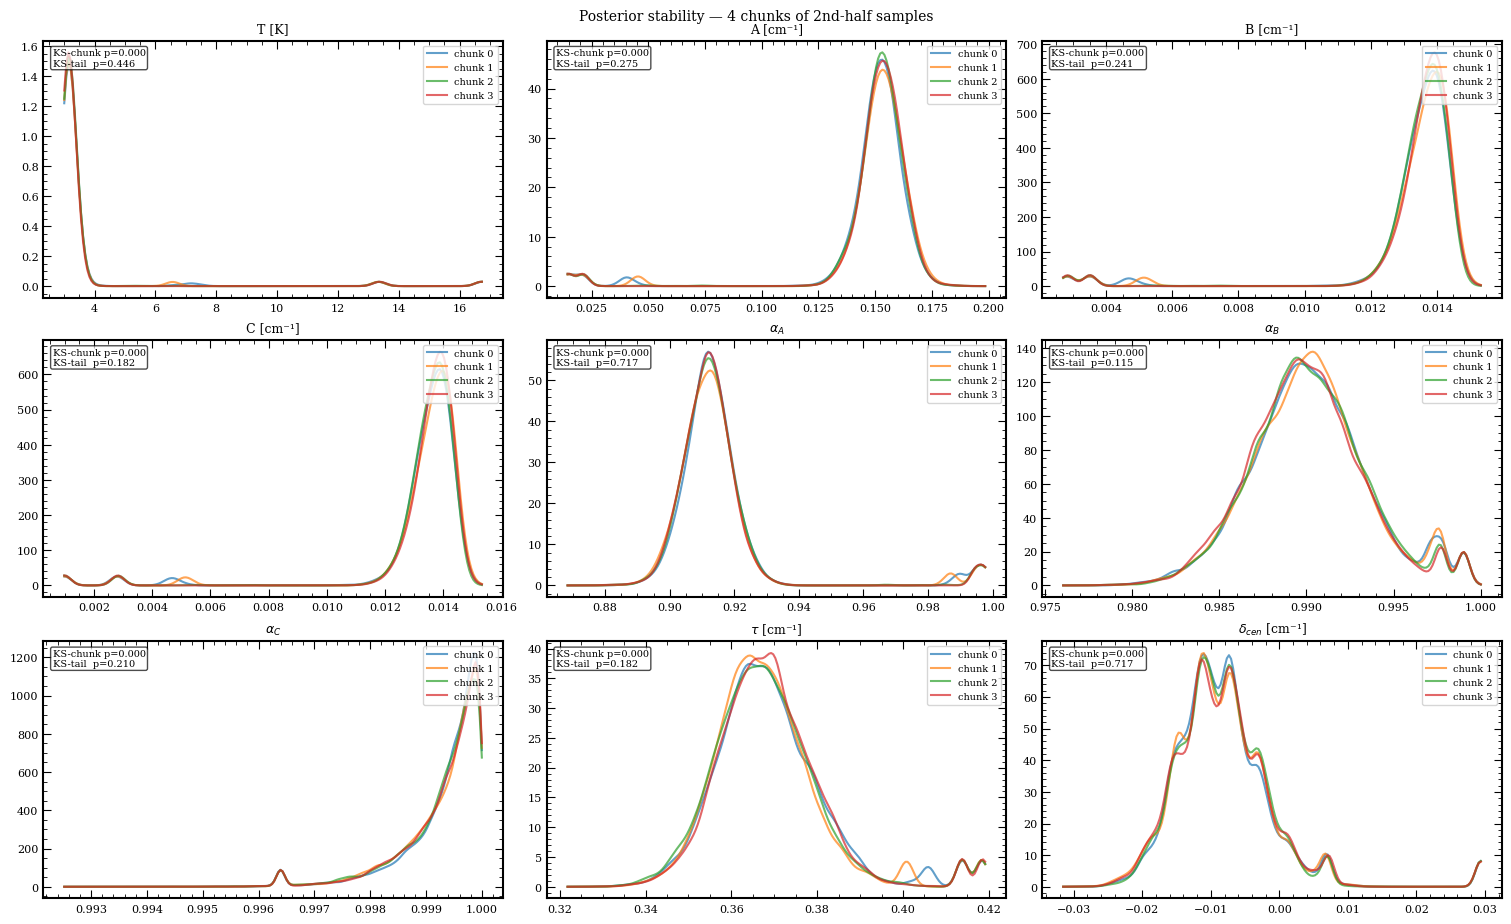

In [47]:
splits = np.array_split(flat_half, 4)

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), constrained_layout=True)
axs = np.array(axs).reshape(nrows, ncols)
fig.suptitle('Posterior stability — 4 chunks of 2nd-half samples', fontsize=10, y=1.01)

for idx in range(ndim):
    r, c = divmod(idx, ncols)
    ax   = axs[r, c]
    xs = np.linspace(flat_half[:, idx].min(), flat_half[:, idx].max(), 200)
    for j, sp in enumerate(splits):
        kde = gaussian_kde(sp[:, idx])
        ax.plot(xs, kde(xs), alpha=0.7, label=f'chunk {j}')
    ax.set_title(labels[idx], fontsize=9)
    ax.tick_params(labelsize=8)
    ann = (f'KS-chunk p={ks_chunks[idx]:.3f}\n'
           f'KS-tail  p={ks_tail[idx]:.3f}')
    ax.text(0.02, 0.97, ann, transform=ax.transAxes, fontsize=7,
            va='top', ha='left', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
    ax.legend(fontsize=7, loc='upper right')

for idx in range(ndim, nrows*ncols):
    r, c = divmod(idx, ncols)
    axs[r, c].set_visible(False)

if save_fig:
    fig.savefig(os.path.join(FIG_DIR, f'stability.pdf'), bbox_inches='tight')
plt.show()

## 11  R-hat & Multimodality Summary

In [48]:
print(f'{"Parameter":<22} {"R-hat":>8} {"R-hat<1.01":>11} {"Peaks":>7} {"Multi?":>8}')
print('-' * 65)
for i, lbl in enumerate(labels):
    rhat_ok  = '✓' if rhat[i] < 1.01  else ('~' if rhat[i] < 1.1 else '✗')
    is_multi = multimodal_peaks[i] > 1
    print(f'{lbl:<22} {rhat[i]:>8.4f}   {rhat_ok:^10}  {multimodal_peaks[i]:>5}   {"YES" if is_multi else "no":>7}')
print('-' * 65)
print(f'\nKS chunk p-values: { {labels[i]: f"{ks_chunks[i]:.3f}" for i in range(ndim)} }')
print(f'KS tail  p-values: { {labels[i]: f"{ks_tail[i]:.3f}"   for i in range(ndim)} }')
print('  (p > 0.05 suggests stationarity)')

Parameter                 R-hat  R-hat<1.01   Peaks   Multi?
-----------------------------------------------------------------
T [K]                    1.5321       ✗           1        no
A [cm⁻¹]                 1.3347       ✗           2       YES
B [cm⁻¹]                 1.3149       ✗           1        no
C [cm⁻¹]                 1.3747       ✗           1        no
$\alpha_A$               1.2989       ✗           2       YES
$\alpha_B$               1.1002       ✗           3       YES
$\alpha_C$               1.1766       ✗           2       YES
$\tau$ [cm⁻¹]            1.0632       ~           3       YES
$\delta_{cen}$ [cm⁻¹]    1.2839       ✗           3       YES
-----------------------------------------------------------------

KS chunk p-values: {'T [K]': '0.000', 'A [cm⁻¹]': '0.000', 'B [cm⁻¹]': '0.000', 'C [cm⁻¹]': '0.000', '$\\alpha_A$': '0.000', '$\\alpha_B$': '0.000', '$\\alpha_C$': '0.000', '$\\tau$ [cm⁻¹]': '0.000', '$\\delta_{cen}$ [cm⁻¹]': '0.000'}
KS tail  p-va

## 12  Last Stored Summary Figure (from run)

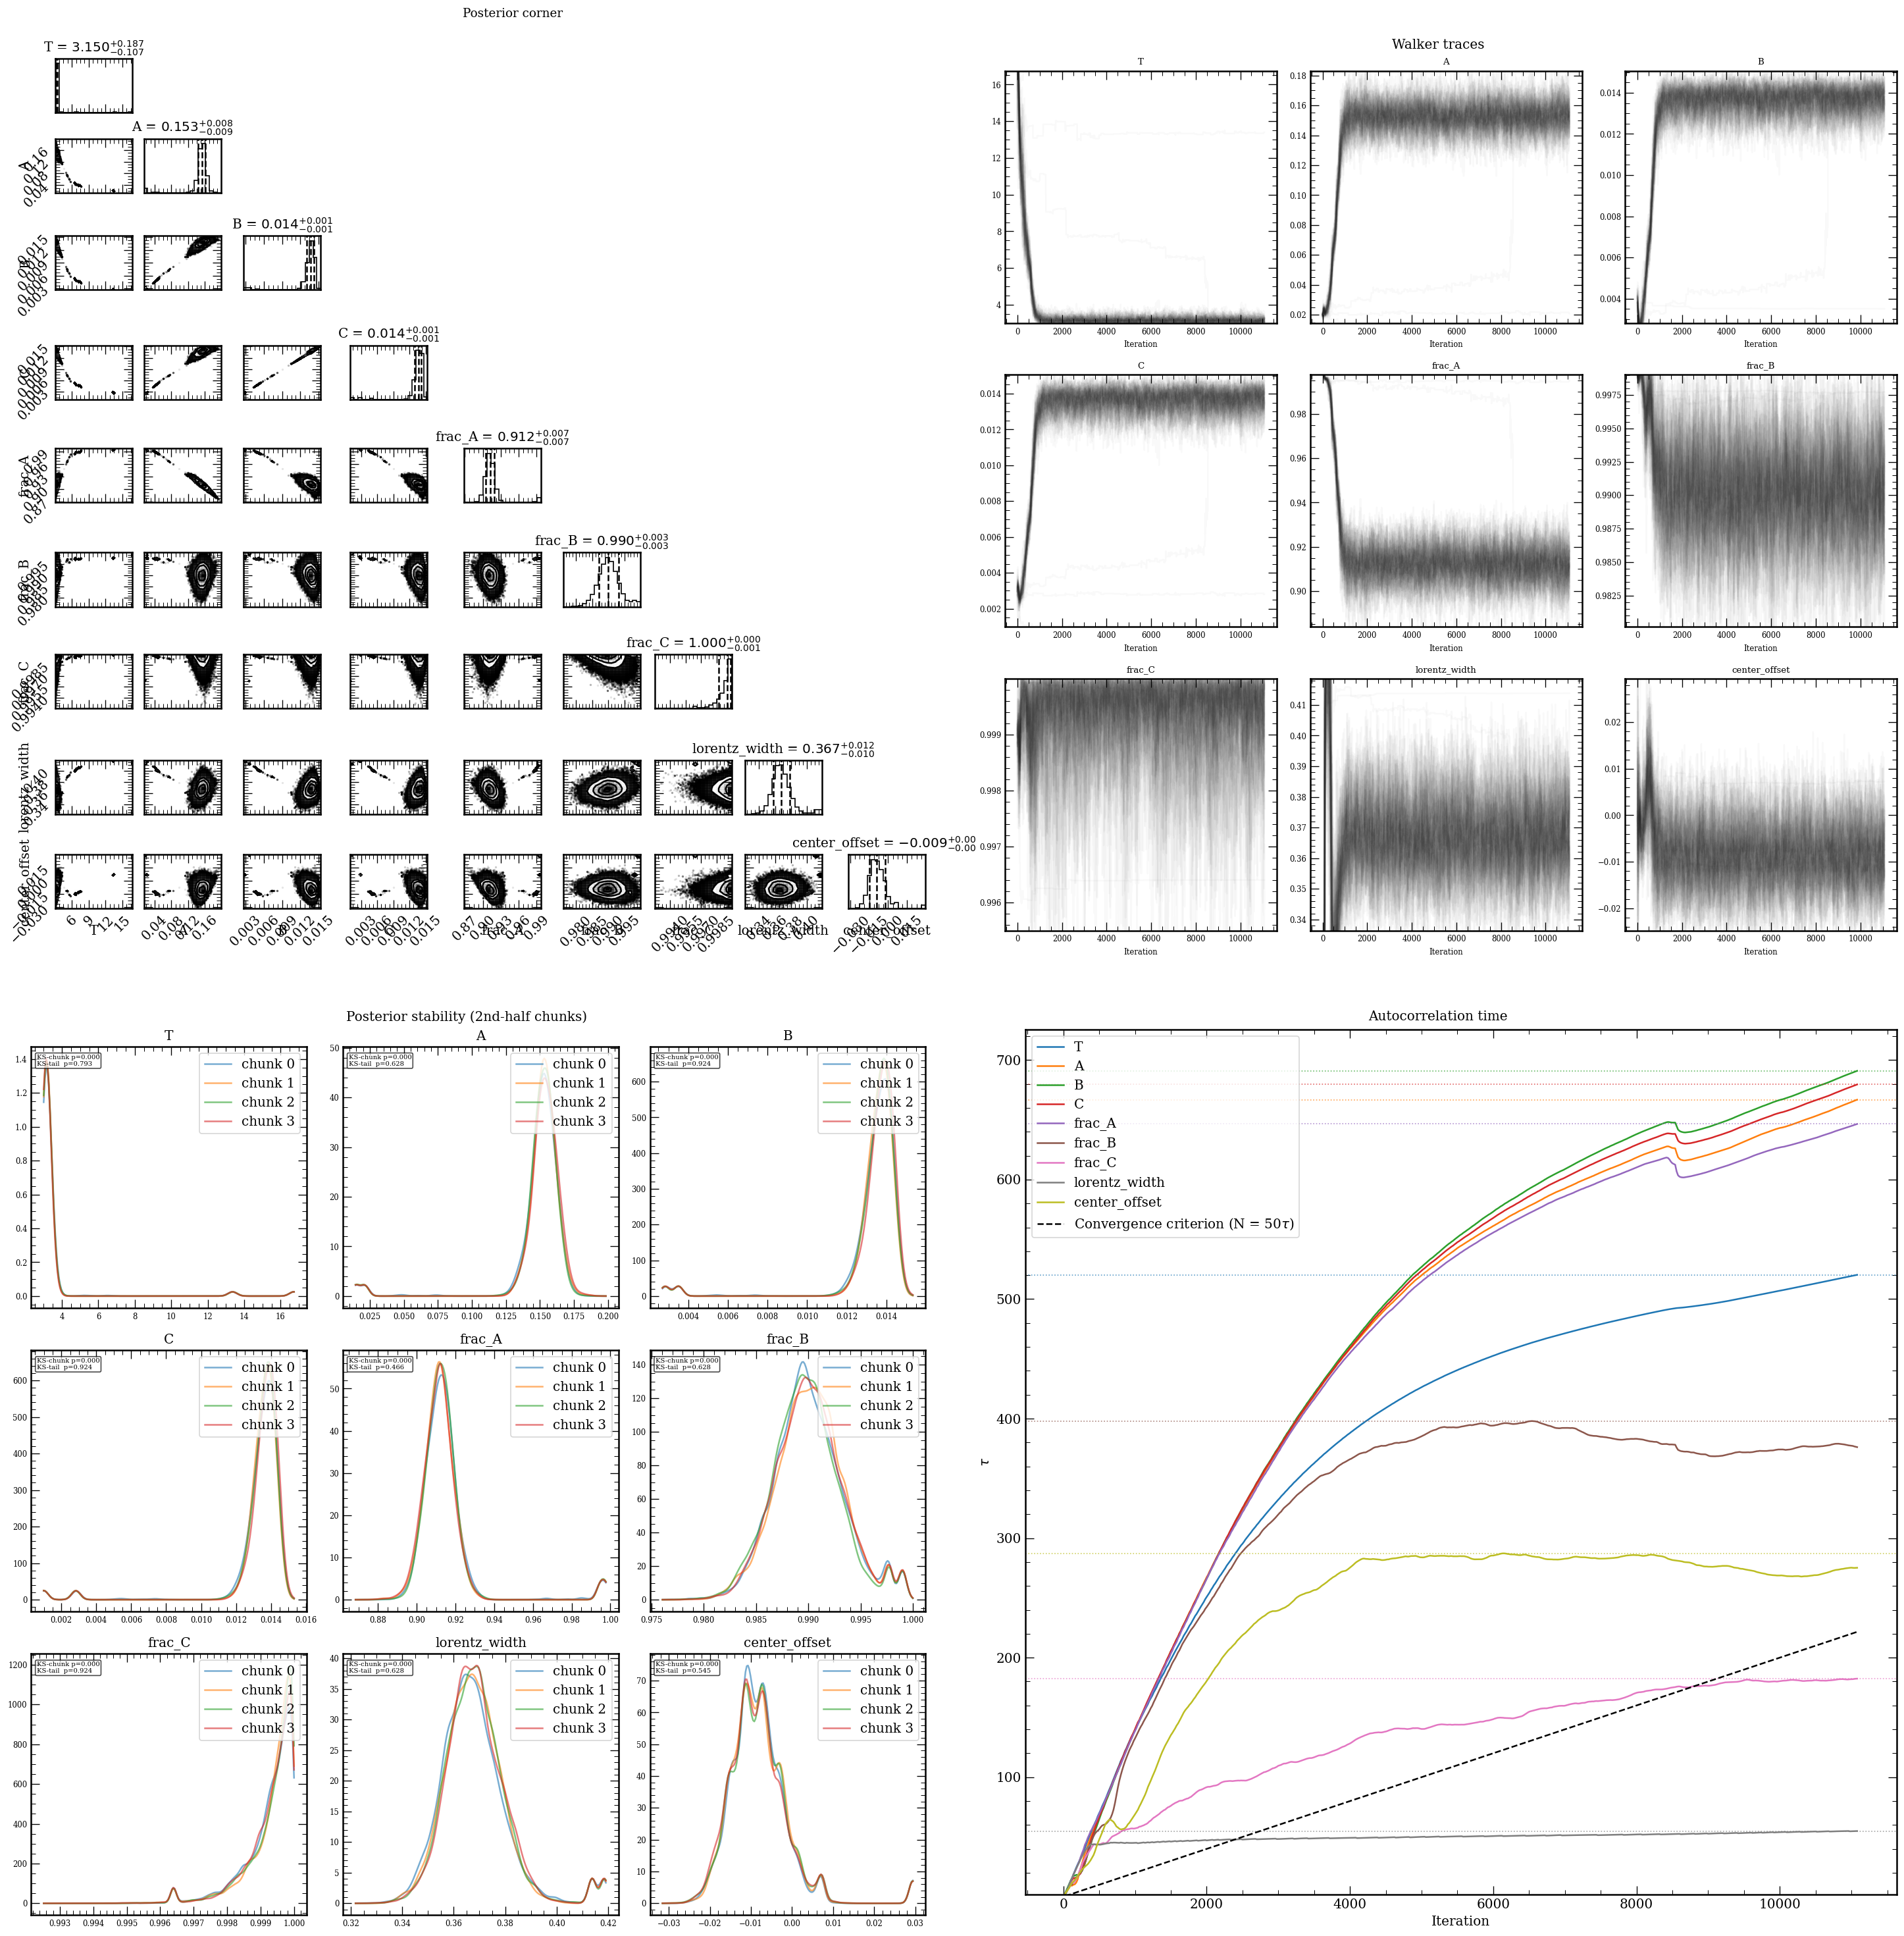

In [49]:
with h5py.File(selected_file, 'r') as f:
    if fig_groups:
        last_grp = fig_groups[-1]
        if 'summary' in f[last_grp]:
            png_bytes = bytes(f[last_grp]['summary'][()])
            display(Image(data=png_bytes, width=900))
        else:
            print('(no summary figure stored in last checkpoint)')

## 13  Burn-in & Flatten Samples

In [50]:
burnin = int(BURNIN_TAU_MULT * np.max(tau))
burnin = max(burnin, 1)
burnin = min(burnin, nsteps - 1)

flat_samples  = chain[burnin:].reshape(-1, ndim)
flat_log_prob = log_prob[burnin:].reshape(-1)

if blobs is not None:
    flat_blobs = blobs[burnin:].reshape(-1, n_blobs)
else:
    flat_blobs = None

# Remove any samples with non-finite log_prob (stuck/rejected)
finite_mask   = np.isfinite(flat_log_prob)
flat_samples  = flat_samples[finite_mask]
flat_log_prob = flat_log_prob[finite_mask]
if flat_blobs is not None:
    flat_blobs = flat_blobs[finite_mask]

print(f'Burn-in:          {burnin} steps  (= {BURNIN_TAU_MULT} * max(tau) = {BURNIN_TAU_MULT} * {np.max(tau):.1f})')
print(f'Remaining steps:  {nsteps - burnin}')
print(f'Total flat samples (finite): {len(flat_samples)}')

Burn-in:          3456 steps  (= 5 * max(tau) = 5 * 691.4)
Remaining steps:  7644
Total flat samples (finite): 489216


## 14  Corner Plot

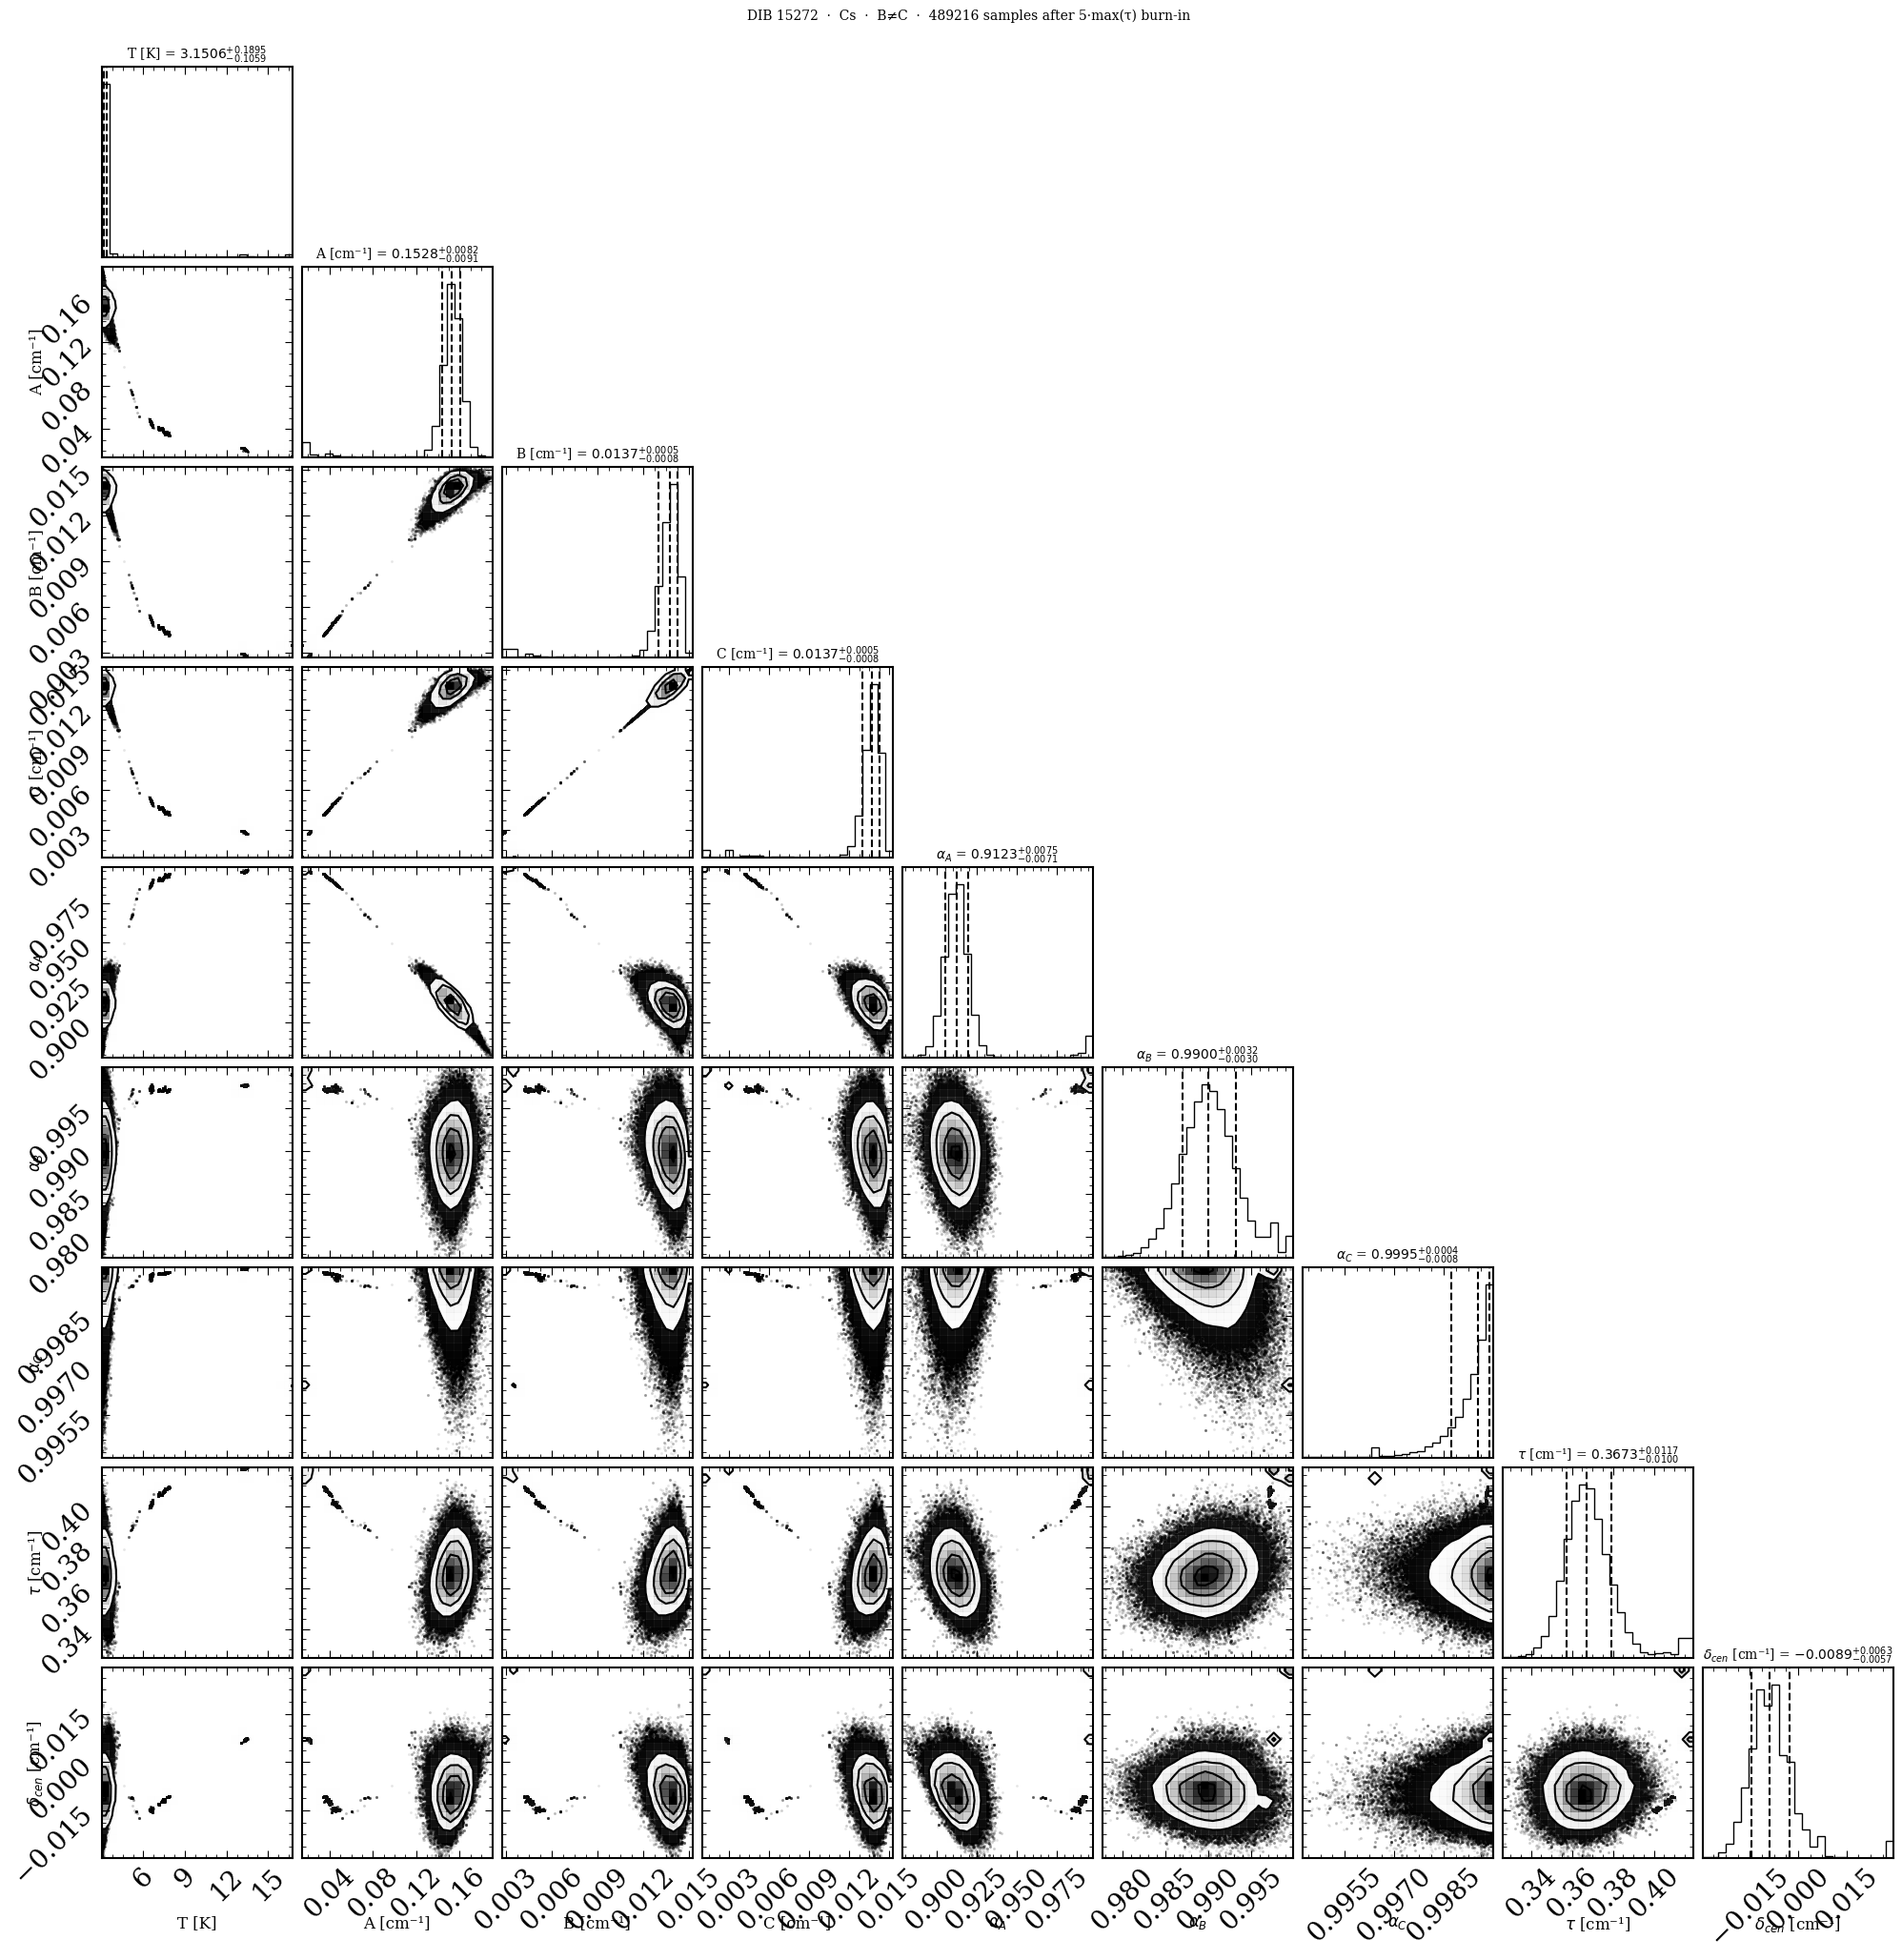

In [51]:
title = (f'DIB {inferred_dib}  ·  {inferred_sym}  ·  '
         f'{"B≠C" if B_not_equal_C else "B=" + ("A" if inferred_sym=="C2v" else "C")}  ·  '
         f'{len(flat_samples)} samples after {BURNIN_TAU_MULT}·max(τ) burn-in')

fig = corner.corner(
    flat_samples,
    labels=labels,
    titles=labels,
    quantiles=[0.16, 0.50, 0.84],
    title_quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt='.4f',
    smooth=0.6,
    bins=25,
    range=[0.9999] * ndim,
    label_kwargs={'fontsize': 12},
    title_kwargs={'fontsize': 10},
)
fig.suptitle(title, fontsize=10, y=1.01)

if save_fig:
    fig.savefig(os.path.join(FIG_DIR, f'corner.pdf'), bbox_inches='tight')
plt.show()

## 14a  Extended Corner — Physical Params + Fit Constants

Extended corner: 15 dims, 489216 samples


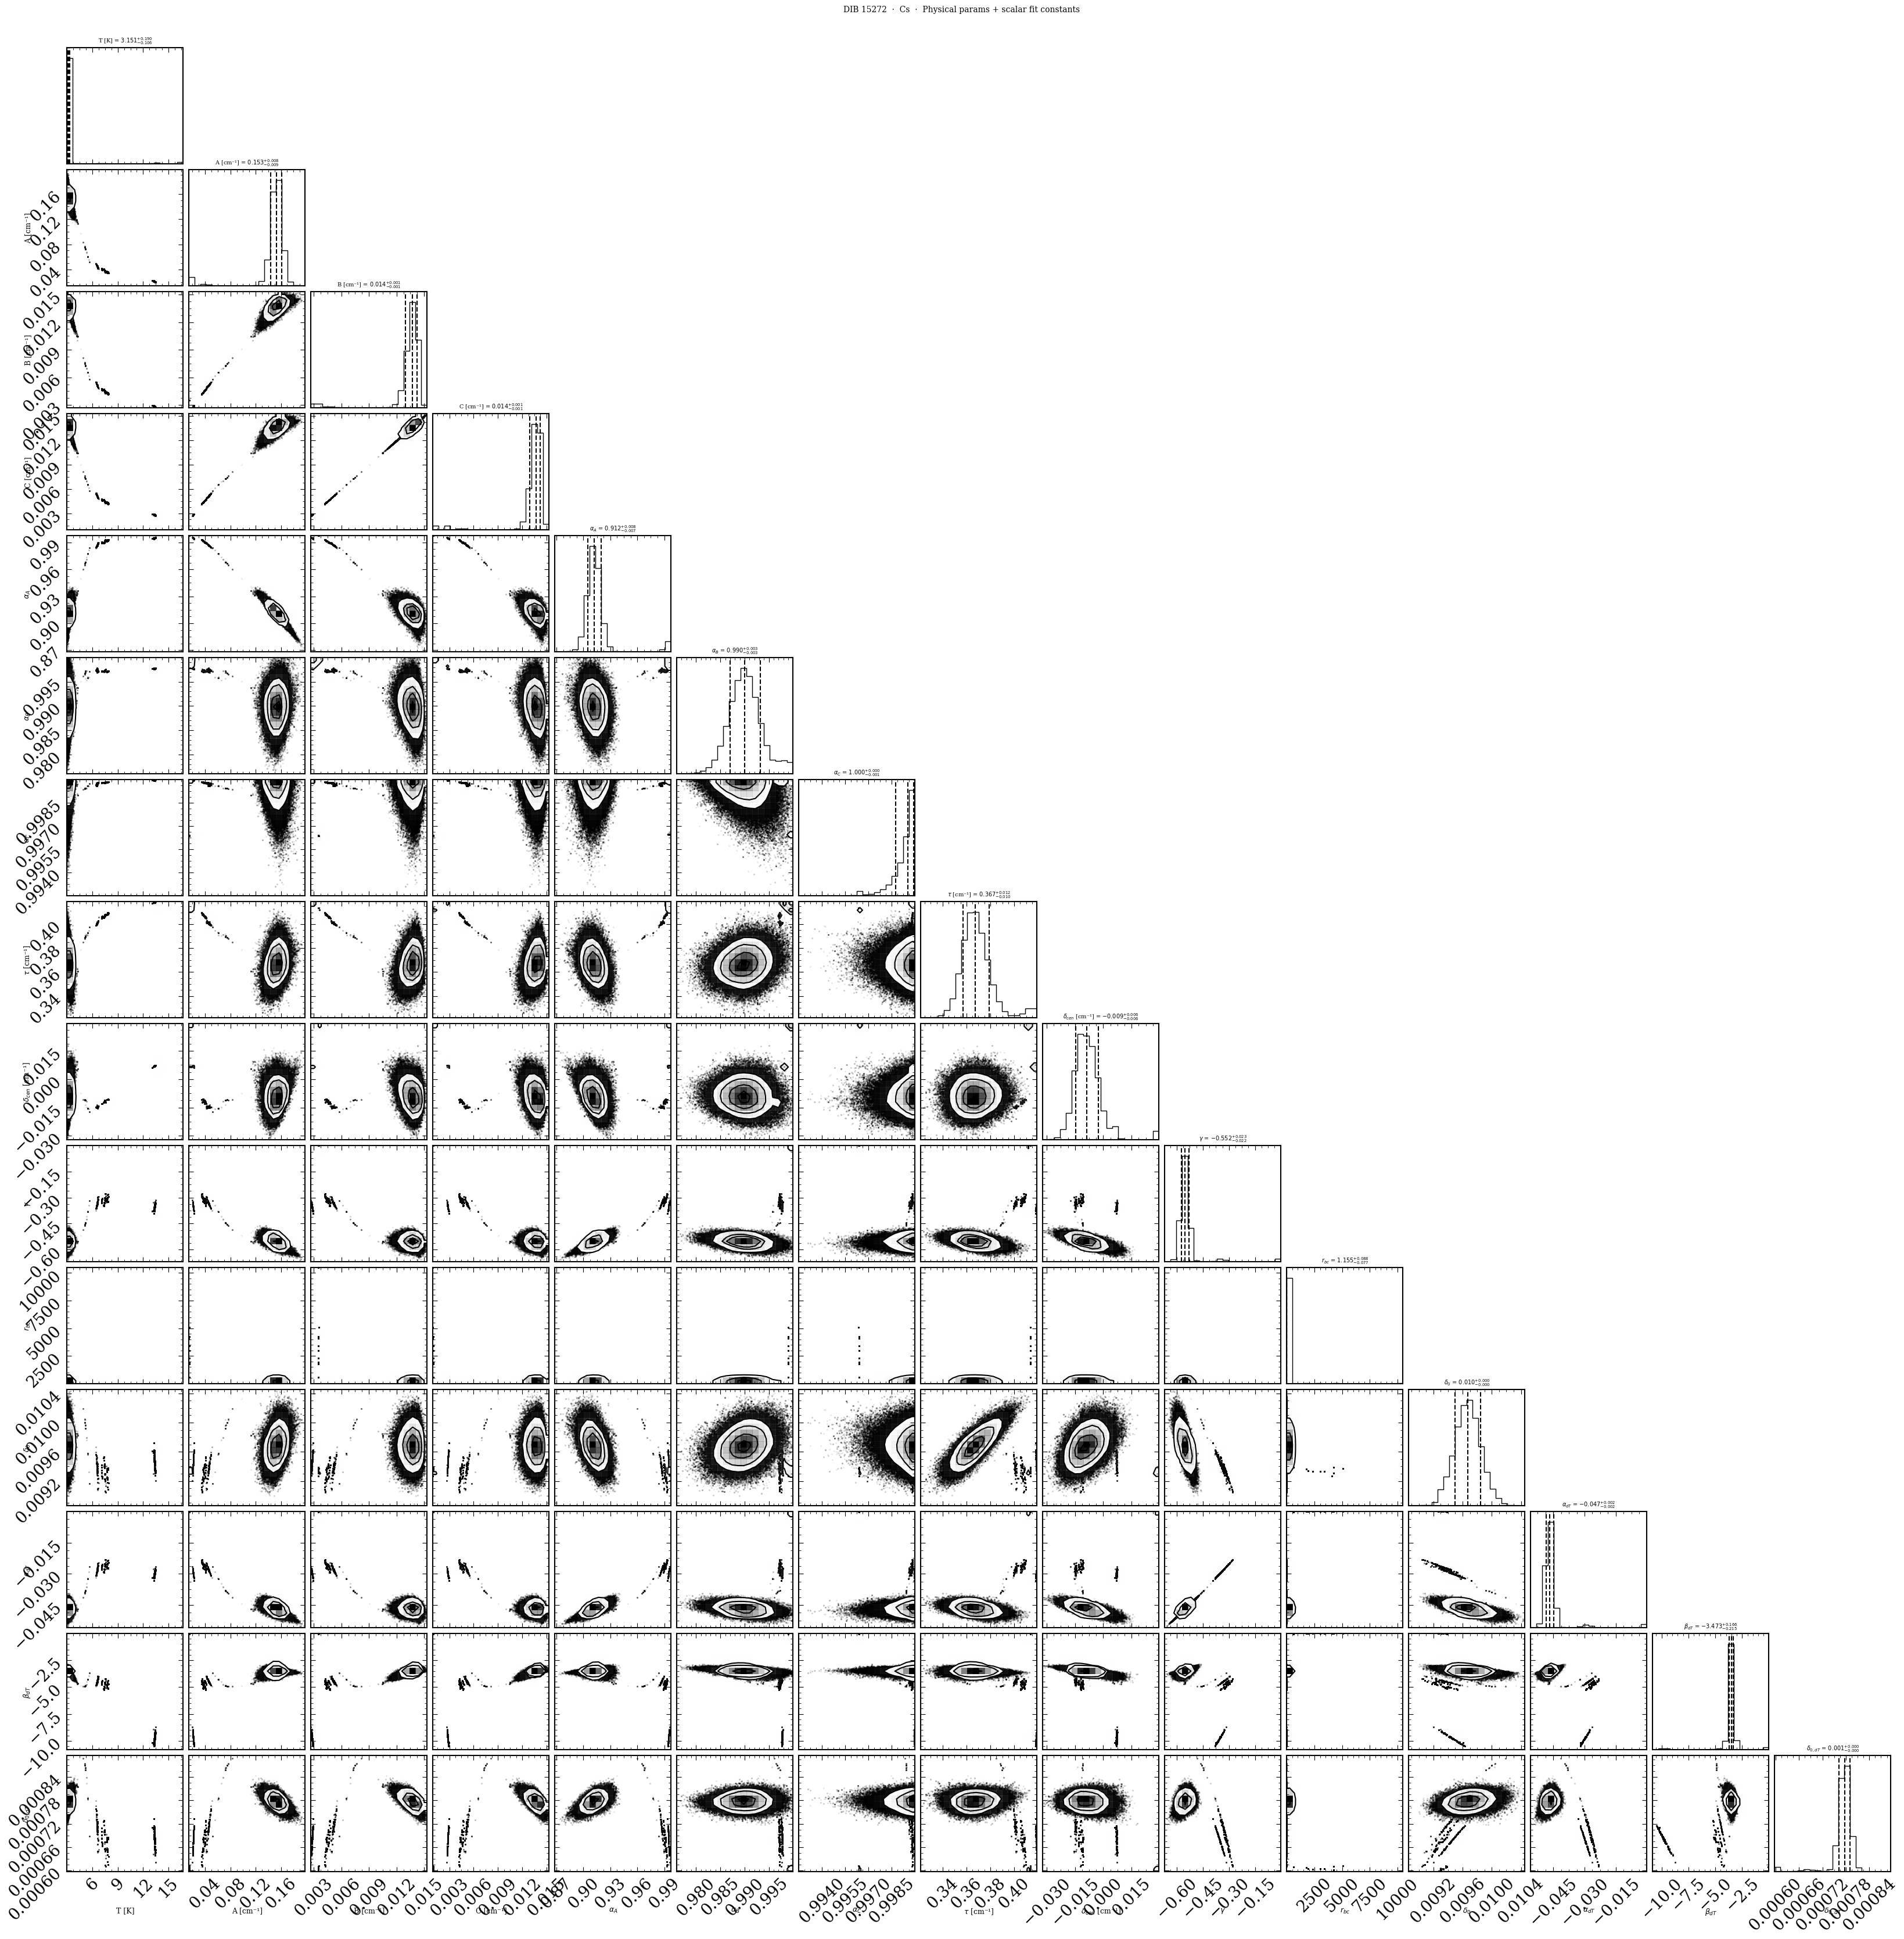

In [52]:
if flat_blobs is None:
    print('No blobs available — skipping extended corner plot.')
else:
    # Blob labels for each possible path
    if n_blobs == 7:  # use_scalar_prior=True Cs
        blob_labels_all = [r'$b_\mathrm{frac}$', r'$c_\mathrm{frac}$', r'$\delta_0$',
                           r'$\alpha_\mathrm{base}$', r'$\beta_b$', r'$\beta_c$', r'$\delta_{0,dT}$']
    else:  # 6-blob: C2v or Cs nonlinear/default
        blob_labels_all = [r'$\gamma$', r'$r_{bc}$', r'$\delta_0$',
                           r'$\alpha_{dT}$', r'$\beta_{dT}$', r'$\delta_{0,dT}$']

    # Drop columns that are entirely NaN (ratio_bc = NaN for C2v)
    valid_cols  = [i for i in range(n_blobs)
                   if not np.all(~np.isfinite(flat_blobs[:, i]))]
    blobs_v     = flat_blobs[:, valid_cols]
    blabels_v   = [blob_labels_all[i] for i in valid_cols]

    combined        = np.hstack([flat_samples, blobs_v])
    combined_labels = labels + blabels_v

    ok = np.all(np.isfinite(combined), axis=1)
    combined = combined[ok]
    print(f'Extended corner: {combined.shape[1]} dims, {len(combined)} samples')

    fig_ext = corner.corner(
        combined,
        labels=combined_labels,
        titles=combined_labels,
        quantiles=[0.16, 0.50, 0.84],
        title_quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_fmt='.3f',
        smooth=0.5,
        bins=20,
        label_kwargs={'fontsize': 9},
        title_kwargs={'fontsize': 7},
    )
    fig_ext.suptitle(
        f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  Physical params + scalar fit constants',
        fontsize=10, y=1.01
    )
    if save_fig:
        fig_ext.savefig(os.path.join(FIG_DIR, f'corner_extended.pdf'), bbox_inches='tight')
    plt.show()


## 14b  Derived-Quantity Corner — dT Response Coefficients

Derived corner: 4 dims, 489216 samples


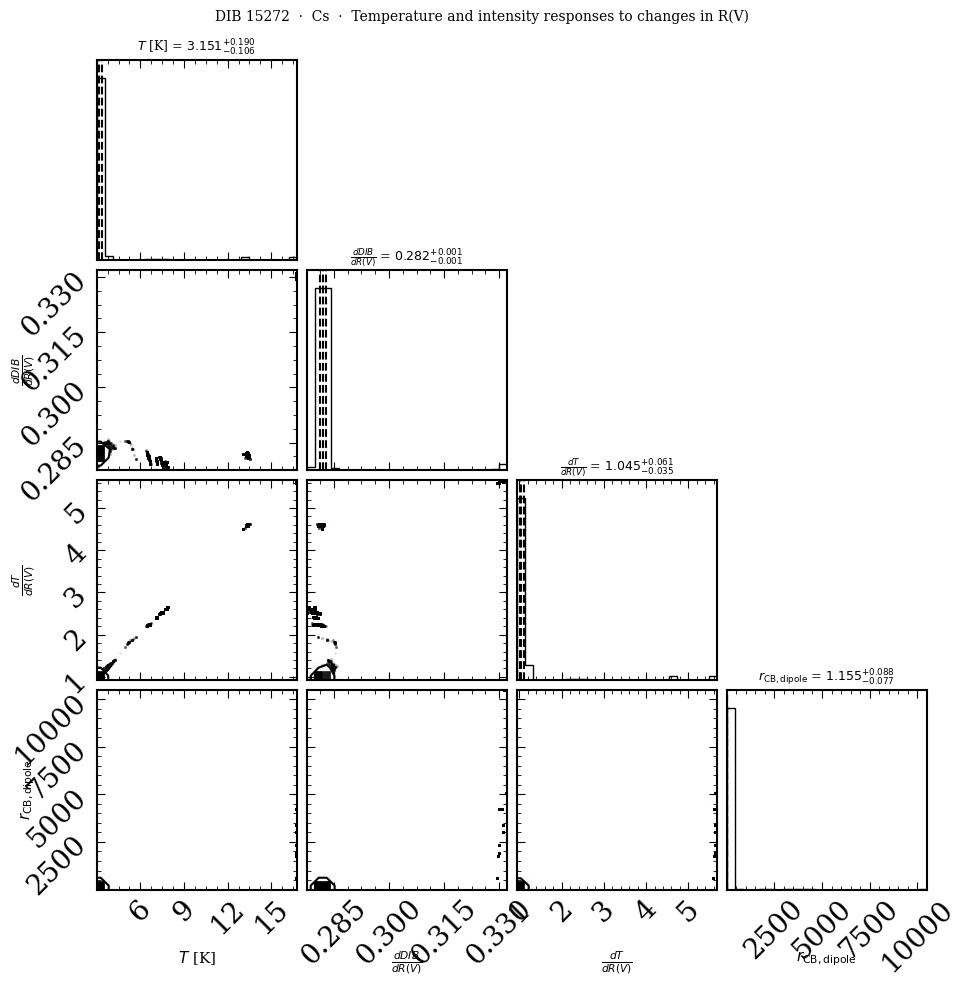

In [53]:
cRV = 0.3
deltaT = 0.05

if flat_blobs is None:
    print('No blobs available — skipping derived-quantity corner plot.')
else:
    if inferred_sym == 'C2v':
        # Blobs layout (all paths): [0]=gamma/b_frac, [3]=alpha_dT/base_frac, [4]=beta_dT/b_frac_dT
        _gamma    = flat_blobs[:, 0]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        T_samps   = flat_samples[:, 0]   # Temperature is always param 0

        # Normalise by gamma: beta/gamma = temperature response per unit DIB strength
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g /cRV   # direct profile contribution to RV derivative dT
        beta_ratio  = deltaT/cRV*_beta_dT  / safe_g   # temperature response / DIB amplitude

        derived = np.column_stack([T_samps, alpha_ratio, beta_ratio])
        derived_labels = [
            r'$T$ [K]',
            r'$\frac{dDIB}{dR(V)}$',
            r'$\frac{dT}{dR(V)}$',
        ]

        ok2 = np.all(np.isfinite(derived), axis=1)
        derived = derived[ok2]
        print(f'Derived corner: {derived.shape[1]} dims, {len(derived)} samples')

        fig_drv = corner.corner(
            derived,
            labels=derived_labels,
            titles=derived_labels,
            quantiles=[0.16, 0.50, 0.84],
            title_quantiles=[0.16, 0.50, 0.84],
            show_titles=True,
            title_fmt='.3f',
            smooth=0.5,
            bins=25,
            label_kwargs={'fontsize': 11},
            title_kwargs={'fontsize': 9},
        )
        fig_drv.suptitle(
            f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  '
            r'Temperature and intensity responses to changes in R(V)',
            fontsize=10, y=1.01
        )
        if save_fig:
            fig_drv.savefig(os.path.join(FIG_DIR, f'corner_dT_coefficients.pdf'), bbox_inches='tight')
        plt.show()
    if inferred_sym == 'Cs':
                # Blobs layout (all paths): [0]=gamma/b_frac, [3]=alpha_dT/base_frac, [4]=beta_dT/b_frac_dT
        _gamma    = flat_blobs[:, 0]
        ratio_bc  = flat_blobs[:, 1]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        T_samps   = flat_samples[:, 0]   # Temperature is always param 0

        # Normalise by gamma: beta/gamma = temperature response per unit DIB strength
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g /cRV   # direct profile contribution to RV derivative dT
        beta_ratio  = deltaT/cRV*_beta_dT  / safe_g   # temperature response / DIB amplitude

        derived = np.column_stack([T_samps, alpha_ratio, beta_ratio, ratio_bc])
        derived_labels = [
            r'$T$ [K]',
            r'$\frac{dDIB}{dR(V)}$',
            r'$\frac{dT}{dR(V)}$',
            r'$r_\mathrm{CB,dipole}$'
        ]

        ok2 = np.all(np.isfinite(derived), axis=1)
        derived = derived[ok2]
        print(f'Derived corner: {derived.shape[1]} dims, {len(derived)} samples')

        fig_drv = corner.corner(
            derived,
            labels=derived_labels,
            titles=derived_labels,
            quantiles=[0.16, 0.50, 0.84],
            title_quantiles=[0.16, 0.50, 0.84],
            show_titles=True,
            title_fmt='.3f',
            smooth=0.5,
            bins=25,
            label_kwargs={'fontsize': 11},
            title_kwargs={'fontsize': 9},
        )
        fig_drv.suptitle(
            f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  '
            r'Temperature and intensity responses to changes in R(V)',
            fontsize=10, y=1.01
        )
        if save_fig:
            fig_drv.savefig(os.path.join(FIG_DIR, f'corner_dT_coefficients.pdf'), bbox_inches='tight')
        plt.show()

## 15  PGOPHER Setup
Define spectrum generation functions (mirroring `run_emcee_asym_both.py`).

In [54]:
PGO_BINARY = os.path.expanduser('~/DIB/./pgo')
pgo_available = os.path.isfile(PGO_BINARY)
if not pgo_available:
    print('⚠  pgo binary not found — profile plot cells will be skipped.')

if inferred_dib == '15272':
    CENTRAL_INVCM_BASE = 1e8 / 15272.27178113337
else:
    CENTRAL_INVCM_BASE = 6381.0

PGO_TEMPLATES = {
    ('C2v', '15272'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15272_C2v.pgo'),
    ('C2v', '15672'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15672_C2v_w_gauss.pgo'),
    ('Cs',  '15272', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_a.pgo'),
    ('Cs',  '15272', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_b.pgo'),
    ('Cs',  '15672', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15672_Cs_a_w_gauss.pgo'),
    ('Cs',  '15672', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15672_Cs_b_w_gauss.pgo'),
}

TEMP_DIR = tempfile.mkdtemp(prefix='dib_analysis_pgo_')
print(f'PGOPHER temp dir: {TEMP_DIR}')

def _fname_base(T, A, B, C, fA, fB, fC, lorentz=0.01, axis='b', co=0.0):
    return (f'T{T:.4f}_A{A:.7f}_B{B:.7f}_C{C:.7f}_'
            f'FA{fA:.5f}_FB{fB:.5f}_FC{fC:.5f}_ax{axis}_lt{lorentz:.3f}_off{co:.2f}')

def _run_pgo(T, A, B, C, fA, fB, fC, lorentz, axis, center_offset, template_key):
    """Template-substitute and run pgo; return path to spectrum text file."""
    PGO_TEMPLATE = PGO_TEMPLATES[template_key]
    A_g, B_g, C_g = A, B, C
    A_e, B_e, C_e = A*fA, B*fB, C*fC
    center = CENTRAL_INVCM_BASE + center_offset
    base   = _fname_base(T, A, B, C, fA, fB, fC, lorentz, axis, center_offset)
    pgo_file  = os.path.join(TEMP_DIR, f'tmp_{base}.pgo')
    spec_file = os.path.join(TEMP_DIR, f'spc_{base}.txt')

    # Build awk substitution script
    # The awk structure differs slightly between C2v/15272, C2v/15672, and Cs.
    # We use the same approach as run_emcee_asym_both.py.
    sym = inferred_sym
    dib = inferred_dib

    if sym == 'C2v' and dib == '15272':
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v axis="{axis}" -v lorentz_width="{lorentz}" '
BEGIN {{ in_ground=0; in_excited=0; }}
/<AsymmetricTop Name="v=0"/ {{ in_ground=1 }}
/<AsymmetricTop Name="v=1"/ {{ in_excited=1 }}
/<\/AsymmetricTop>/ {{ in_ground=0; in_excited=0 }}
in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"" axis "\\"") }}
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="Lorentzian" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""
    else:  # C2v/15672 or any Cs — both use Origin + manifest names
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v lorentz_width="{lorentz}" -v center="{center}" '
BEGIN {{ inside_ground=0; inside_excited=0; }}
/<Parameter Name="Temperature" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<AsymmetricManifold Name="Ground"/ {{ inside_ground=1 }}
/<AsymmetricManifold Name="Excited"/ {{ inside_excited=1 }}
/<\/AsymmetricManifold>/ {{ inside_ground=0; inside_excited=0 }}
inside_ground  && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
inside_ground  && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
inside_ground  && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
inside_excited && /<Parameter Name="Origin" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" center "\\"") }}
inside_excited && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
inside_excited && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
inside_excited && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<Parameter Name="Lorentzian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""

    subprocess.run(awk_script, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BINARY, '--plot', pgo_file, spec_file],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return spec_file


def get_pgopher_spectrum(spec_file, center_offset=0.0, dlam=0.01, window=8):
    """Load a PGOPHER spectrum txt and interpolate to data_wavelength grid,
    applying the analytical 3-Gaussian LSF if needed."""
    inv_cm, flux = np.loadtxt(spec_file).T
    wav_pgo = 1e8 / inv_cm

    do_convolve = not (inferred_dib == '15672' and inferred_sym == 'C2v')

    if do_convolve:
        center_invcm = CENTRAL_INVCM_BASE + center_offset
        wavc    = 1e8 / center_invcm
        wav_reg = np.arange(wavc - window, wavc + window, dlam)
        f_i     = interp1d(wav_pgo, flux, bounds_error=False, fill_value=0.0)
        flux_r  = f_i(wav_reg)

        sig1, sig2, sig3 = 0.3, 1.85*0.3, 9.5*0.3
        f1, f2 = 0.895, 0.1
        c0     = 1.3e-3
        rel    = wav_reg - wavc
        lsf    = (f1     / np.sqrt(2*np.pi*sig1**2) * np.exp(-rel**2 / (2*sig1**2)) +
                  f2     / np.sqrt(2*np.pi*sig2**2) * np.exp(-rel**2 / (2*sig2**2)) +
                  (1-f1-f2) / np.sqrt(2*np.pi*sig3**2) * np.exp(-rel**2 / (2*sig3**2)) + c0)
        lsf   /= lsf.sum()
        conv   = fftconvolve(flux_r, lsf, mode='same')
        out_i  = interp1d(wav_reg, conv, bounds_error=False, fill_value=0.0)
    else:
        out_i  = interp1d(wav_pgo, flux, bounds_error=False, fill_value=0.0)

    return out_i(data_wavelength)


def unpack_params(params):
    """Return (T, A, B, C, fA, fB, fC, lorentz, center_offset) from a flat param vector."""
    if B_not_equal_C:
        if has_center_offset:
            T, A, B, C, fA, fB, fC, lt, co = params
        else:
            T, A, B, C, fA, fB, fC, lt = params; co = 0.0
    else:
        if has_center_offset:
            T, A, C, fA, fC, lt, co = params
        else:
            T, A, C, fA, fC, lt = params; co = 0.0
        if inferred_sym == 'C2v':
            B, fB = A, fA
        else:  # Cs
            B, fB = C, fC
    return T, A, B, C, fA, fB, fC, lt, co


def generate_spectra(params):
    """Run PGOPHER for a param vector; return (model_flux, model_flux_dT) on data_wavelength."""
    T, A, B, C, fA, fB, fC, lt, co = unpack_params(params)
    if inferred_sym == 'C2v':
        tkey = ('C2v', inferred_dib)
        sf      = _run_pgo(T,      A, B, C, fA, fB, fC, lt, 'a', co, tkey)
        sf_dT   = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, 'a', co, tkey)
        mf    = get_pgopher_spectrum(sf,    co)
        mf_dT = get_pgopher_spectrum(sf_dT, co)
        return {'C2v': (mf, mf_dT)}
    else:  # Cs — two axes
        results = {}
        for axis in ('a', 'b'):
            tkey  = ('Cs', inferred_dib, axis)
            sf    = _run_pgo(T,      A, B, C, fA, fB, fC, lt, axis, co, tkey)
            sf_dT = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, axis, co, tkey)
            results[axis] = (get_pgopher_spectrum(sf, co),
                             get_pgopher_spectrum(sf_dT, co))
        return results


def reconstruct_model(spectra_dict, blob_row):
    """From PGOPHER spectra + blob scalars (or rerun), return (model_dib, model_dT) on the
    cropped wavelength grid [c_crop:-c_crop]."""
    c, gf = c_crop, gf_sigma

    if inferred_sym == 'C2v':
        mf, mf_dT = spectra_dict['C2v']
        spec    = gaussian_filter(mf[c:-c],    gf)
        spec_dT = gaussian_filter(mf_dT[c:-c], gf) - spec

        if rerun_coefficients:
            meas      = data_flux[c:-c]
            meas_dT   = data_flux_dT[c:-c]
            M         = np.vstack([spec, np.ones_like(spec)]).T
            gamma, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            M_dT      = np.vstack([spec, spec_dT, np.ones_like(spec)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
        else:
            gamma, _, offset, alpha_dT, beta_dT, offset_dT = blob_row[:6]

        model_dib = gamma * spec + offset
        model_dT  = alpha_dT * spec + beta_dT * spec_dT + offset_dT
        return model_dib, model_dT

    else:  # Cs
        mf_b,  mf_dT_b  = spectra_dict['a']  # a-axis = b-type
        mf_c,  mf_dT_c  = spectra_dict['b']  # b-axis = c-type
        spec_b    = gaussian_filter(mf_b[c:-c],    gf)
        spec_c    = gaussian_filter(mf_c[c:-c],    gf)
        spec_dT_b = gaussian_filter(mf_dT_b[c:-c], gf) - spec_b
        spec_dT_c = gaussian_filter(mf_dT_c[c:-c], gf) - spec_c

        if rerun_coefficients:
            meas    = data_flux[c:-c]
            meas_dT = data_flux_dT[c:-c]
            M       = np.vstack([spec_b, spec_c, np.ones_like(spec_b)]).T
            b_frac, c_frac, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            ratio   = b_frac / (c_frac + 1e-10)
            base    = spec_b + ratio * spec_c
            delta_b = spec_dT_b
            delta_c = spec_dT_c
            M_dT    = np.vstack([base, delta_b + ratio * delta_c, np.ones_like(base)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
            base_frac_dT = 0.0
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = alpha_dT * base + beta_dT * (delta_b + ratio * delta_c) + offset_dT
        elif n_blobs == 7:  # use_scalar_prior=True path
            b_frac, c_frac, offset, base_frac_dT, b_frac_dT, c_frac_dT, offset_dT = blob_row[:7]
            ratio     = b_frac / (c_frac + 1e-10)
            base      = spec_b + ratio * spec_c
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = (base_frac_dT * base +
                         b_frac_dT * spec_dT_b + c_frac_dT * spec_dT_c + offset_dT)
        else:  # 6-blob nonlinear path
            gamma, ratio_bc, offset_spec, alpha_dT, beta_dT, offset_dT = blob_row[:6]
            base      = spec_b + ratio_bc * spec_c
            delta     = spec_dT_b + ratio_bc * spec_dT_c
            model_dib = gamma * base + offset_spec
            model_dT  = alpha_dT * base + beta_dT * delta + offset_dT

        return model_dib, model_dT

print('PGOPHER helper functions defined.')
print(f'pgo binary: {"found" if pgo_available else "NOT FOUND — profile plot will be skipped"}')

PGOPHER temp dir: /tmp/dib_analysis_pgo_2ctl0eib
PGOPHER helper functions defined.
pgo binary: found


## 16  Draw Posterior Samples & Generate Model Spectra

In [55]:
if not pgo_available:
    print('Skipping profile plot — pgo binary not available.')
else:
    np.random.seed(42)
    sample_idx = np.random.choice(len(flat_samples), size=n_samples, replace=False)

    models_dib = []
    models_dT  = []

    print(f'Generating {n_samples} posterior spectra via PGOPHER...')
    for k, si in enumerate(sample_idx):
        params     = flat_samples[si]
        blob_row   = flat_blobs[si] if flat_blobs is not None else None
        try:
            spectra    = generate_spectra(params)
            mdib, mdT  = reconstruct_model(spectra, blob_row)
            models_dib.append(mdib)
            models_dT.append(mdT)
            print(f'  [{k+1}/{n_samples}]  T={params[0]:.3f} K  done')
        except Exception as e:
            print(f'  [{k+1}/{n_samples}]  FAILED: {e}')
            models_dib.append(None)
            models_dT.append(None)

    models_dib = [m for m in models_dib if m is not None]
    models_dT  = [m for m in models_dT  if m is not None]
    print(f'Successfully generated {len(models_dib)} / {n_samples} model spectra.')

Generating 25 posterior spectra via PGOPHER...
  [1/25]  T=3.152 K  done
  [2/25]  T=3.120 K  done
  [3/25]  T=3.125 K  done
  [4/25]  T=3.039 K  done
  [5/25]  T=3.495 K  done
  [6/25]  T=3.179 K  done
  [7/25]  T=3.046 K  done
  [8/25]  T=3.037 K  done
  [9/25]  T=3.091 K  done
  [10/25]  T=3.074 K  done



KeyboardInterrupt



In [ ]:
blobs[-1][0], np.all(blobs[:,0,0]==0)

## 18  Profile Figure — χ², Errorbars, Two Error Versions

In [ ]:
import re
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

if not pgo_available or not models_dib:
    print('No model spectra available — skipping profile figure.')
else:
    c          = c_crop
    wav_full   = data_wavelength
    wav_centre = 1e8 / CENTRAL_INVCM_BASE

    wav_crop   = data_wavelength[c:-c]

    dat_dib = data_flux
    dat_dT  = data_flux_dT

    # ── Error versions ───────────────────────────────────────────────────────
    err_type_str = 'Plate' if use_plate_errs else ('Old' if use_old_errs else 'Default')
    err_dib_cur  = noise_std
    err_dT_cur   = noise_std_dT

    err_sets = [
        (err_dib_cur, err_dT_cur, f'{err_type_str} errors  [used in fit]', True),
    ]
    try:
        with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
            _pe_dib = (np.sqrt(pf['var'][:, 0]) * fudge)
            _pe_dT  = (np.sqrt(pf['var'][:, 1]) * fudge)
        if not use_plate_errs:
            err_sets.append((_pe_dib, _pe_dT, 'Plate jackknife errors  [not used in fit]', False))
    except Exception:
        pass
    if use_plate_errs:
        try:
            with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as df:
                _df_dib = (np.sqrt(df['var'][:, 0]) * fudge)
                _df_dT  = (np.sqrt(df['var'][:, 1]) * fudge)
            err_sets.append((_df_dib, _df_dT, 'Default errors  [not used in fit]', False))
        except Exception:
            pass

    # ── Median models ────────────────────────────────────────────────────────
    med_dib = np.median(np.array(models_dib), axis=0)
    med_dT  = np.median(np.array(models_dT),  axis=0)

    # ── DoF per panel ────────────────────────────────────────────────────────
    if inferred_sym == 'C2v':
        n_spec_sc, n_dT_sc = 2, 3
    elif n_blobs == 7:
        n_spec_sc, n_dT_sc = 3, 4
    else:
        n_spec_sc, n_dT_sc = 3, 3

    def chi2_stats(data, models_list, err, n_scalar):
        data_c = data[c:-c]
        err_c  = err[c:-c]
        dof    = len(data_c) - ndim - n_scalar
        cv_samps = np.array([np.sum(((data_c - m) / err_c)**2) for m in models_list])
        cr_samps = cv_samps / dof if dof > 0 else np.full_like(cv_samps, np.nan)
        pv_samps = np.array([float(chi2_dist.sf(cv, dof)) for cv in cv_samps]) if dof > 0 \
                   else np.full_like(cv_samps, np.nan)
        cv  = float(np.median(cv_samps));  se_cv = float(np.std(cv_samps))
        cr  = float(np.median(cr_samps));  se_cr = float(np.std(cr_samps))
        pv  = float(np.median(pv_samps));  se_pv = float(np.std(pv_samps))
        return cv, cr, pv, dof, se_cv, se_cr, se_pv

    # ── Derived quantities ───────────────────────────────────────────────────
    if inferred_sym == 'C2v':
        _gamma    = flat_blobs[:, 0]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g / cRV
        beta_ratio  = deltaT / cRV * _beta_dT / safe_g
        derived = np.column_stack([alpha_ratio, beta_ratio])
        derived_labels = [r'$\frac{dDIB}{dR(V)}$', r'$\frac{dT}{dR(V)}$']
        derived_units  = ['', r'$\mathrm{K}$']

    if inferred_sym == 'Cs':
        _gamma    = flat_blobs[:, 0]
        ratio_bc  = flat_blobs[:, 1]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g / cRV
        beta_ratio  = deltaT / cRV * _beta_dT / safe_g
        derived = np.column_stack([alpha_ratio, beta_ratio, ratio_bc])
        derived_labels = [r'$\frac{dDIB}{dR(V)}$', r'$\frac{dT}{dR(V)}$', r'$r_\mathrm{CB}$']
        derived_units  = ['', r'$\mathrm{K}$', '']

    variation_txt = "\n".join(
        f"{label} = {np.median(derived[:, i]):.2f} ± "
        f"{np.diff(np.percentile(derived[:, i], [16, 84]))[0] / 2:.2f} {derived_units[i]}"
        for i, label in enumerate(derived_labels)
    )

    def parse_label(label):
        label = label.strip()
        unit_match = re.search(r'\[([^\]]+)\]', label)
        unit = unit_match.group(1) if unit_match else ''
        name = re.sub(r'\s*\[[^\]]+\]', '', label).strip().strip('$')
        return name, unit

    param_txt = "\n".join(
        r"${name} = {med:.2f}^{{+{up:.2f}}}_{{-{lo:.2f}}}$ {unit}".format(
            name=name,
            med=np.median(flat_samples[:, i]),
            up=np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]),
            lo=np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16),
            unit=unit,
        )
        for i, label in enumerate(labels[:-1])
        for name, unit in [parse_label(label)]
    )

    # ── Figure layout: each row has 2 columns, each column has main + residual
    DARK_RED = '#8B0000'
    SAMP_COL = 'k'
    MED_COL  = 'k'
    n_rows   = len(err_sets)

    fig18 = plt.figure(figsize=(16, 7 * n_rows), constrained_layout = False)
    outer_gs = GridSpec(n_rows, 2, figure=fig18)

    # Store axes for annotation after loop
    all_ax_main = np.empty((n_rows, 2), dtype=object)
    all_ax_res  = np.empty((n_rows, 2), dtype=object)

    for row, (e_dib, e_dT, err_label, is_fit) in enumerate(err_sets):
        for col, (dat, err, models, med, panel_title, ylabel, n_sc) in enumerate([
            (dat_dib, e_dib, models_dib, med_dib,
             'DIB profile', 'Flux (normalised)', n_spec_sc),
            (dat_dT,  e_dT,  models_dT,  med_dT,
             r'$\partial\mathrm{DIB}/\partial T$', r'$\Delta$Flux/$\Delta T$', n_dT_sc),
        ]):
            # Inner GridSpec: main (5) + residual (1)
            inner_gs = GridSpecFromSubplotSpec(
                2, 1, subplot_spec=outer_gs[row, col],
                height_ratios=[5, 1], hspace=0.0
            )
            ax     = fig18.add_subplot(inner_gs[0])
            ax_res = fig18.add_subplot(inner_gs[1], sharex=ax)
            all_ax_main[row, col] = ax
            all_ax_res[row, col]  = ax_res

            # ── Main panel ───────────────────────────────────────────────────
            ax.errorbar(wav_full, dat, yerr=err,
                        fmt='o', color=DARK_RED, ecolor=DARK_RED,
                        markersize=2, elinewidth=0.8, capsize=2, alpha=0.85,
                        label=r'Data $\pm 1\sigma$')
            for k, m in enumerate(models):
                ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                        label=f'{len(models)} posterior draws' if k == 0 else None)
            ax.plot(wav_crop, med, color=MED_COL, lw=1.8, ls='--', label='Posterior median')

            cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(dat, models, err, n_sc)
            ax.annotate(
                f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
                f'dof={dof}\n'
                f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$\n'
                f'$p = {pv:.3f} \\pm {se_pv:.3f}$',
                xy=(0.05, 0.6), xycoords='axes fraction',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

            ax.set_ylabel(ylabel)
            ax.set_title(f'{panel_title}   [{err_label}]')
            ax.legend(loc='lower left')
            ax.tick_params(which='both', direction='in', top=True, right=True)
            ax.tick_params(labelbottom=False)

            # ── Residual panel ───────────────────────────────────────────────
            chi_dev = (dat[c:-c] - med) / err[c:-c]
            ax_res.axhline(0, color='k', lw=2, ls='--')
            ax_res.axhline(-1, color='k', alpha = 0.5, lw=1, ls='--')
            ax_res.axhline(1, color='k', alpha = 0.5, lw=1, ls='--')            
            ax_res.plot(wav_crop, chi_dev, 'ko', lw=0.8)
            ax_res.set_ylabel(r'$\chi$', fontsize=8)
            ax_res.set_xlabel(r'Wavelength [Å]')
            
            max_dev = np.max([1, np.max(np.abs(chi_dev))])
            fac = 1.2
            ax_res.set_ylim([-fac*max_dev, fac*max_dev])
            ax_res.tick_params(which='both', direction='in', top=True, right=True, labelsize=8)
            ax_res.yaxis.set_major_locator(plt.MaxNLocator(3, symmetric=True))

        # ── Annotations ──────────────────────────────────────────────────────
        all_ax_main[row, 1].annotate(
            variation_txt,
            xy=(0.675, 0.45), xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

        all_ax_main[row, 0].annotate(
            param_txt,
            xy=(0.67, 0.7), xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

    _bnc_str   = 'B≠C' if B_not_equal_C else ('B=C' if inferred_sym == 'C2v' else 'B=C')
    _coeff_str = 'stored blobs' if not rerun_coefficients else 'recomputed coefficients'
    fig18.suptitle(
        f'DIB {inferred_dib}  ·  {inferred_sym}  ·  {_bnc_str}  ·  '
        f'{len(models_dib)} draws  ·  {_coeff_str}',
        fontsize=24
    )
    if save_fig:
        fig18.savefig(os.path.join(FIG_DIR, f'profiles_chi2.pdf'), bbox_inches='tight')
    plt.show()

    import shutil
    shutil.rmtree(TEMP_DIR, ignore_errors=True)
    print(f'Cleaned up temp dir: {TEMP_DIR}')

## 19  PCA Temperature Derivative — 3-Column Comparison
Same molecular parameters as the MCMC fit; linear scalars re-fitted against the PCA dT measurement.

In [ ]:
if not pgo_available or not models_dib:
    print('No model spectra available — skipping PCA comparison figure.')
else:
    if dib_band == '15672':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15672_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')
    if dib_band == '15272':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15272_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5')
    try:
        pca_meas = pd.read_csv(PCA_FILE, sep=r'\s+',
                               names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
        wav_pca  = pca_meas['wavelength'].values
        with h5py.File(OLD_ERR_FILE, 'r') as ef:
            dat_pca_dib = pca_meas['PC1_1'].values
            dat_pca_dT  = pca_meas['PC2_2'].values
            err_pca_dib = np.sqrt(ef['var'][:, 0]) * fudge
            err_pca_dT  = np.sqrt(ef['var'][:, 1]) * fudge
        pca_loaded = True
    except Exception as ex:
        print(f'Could not load PCA data: {ex}')
        pca_loaded = False

    if pca_loaded:
#         c_pca          = 30 #for 15272 old pca_version
        if dib_band == '15672':
            c_pca          = 20
        if dib_band == '15272':
            c_pca          = 10
        wav_pca_crop   = wav_pca[c_pca:-c_pca]
        pca_dT_crop    = dat_pca_dT[c_pca:-c_pca]
        err_pca_dT_c   = err_pca_dT[c_pca:-c_pca]
        err_pca_dib_c  = err_pca_dib[c_pca:-c_pca]

        c        = c_crop
        wav_crop = data_wavelength[c:-c]
        wav_off  = wav_crop - (1e8 / CENTRAL_INVCM_BASE)

        # Scalar DoF
        if inferred_sym == 'C2v':
            n_spec_sc, n_dT_sc = 2, 3
        elif n_blobs == 7:
            n_spec_sc, n_dT_sc = 3, 4
        else:
            n_spec_sc, n_dT_sc = 3, 3

        # ── For each sample: interpolate to PCA grid, re-fit 3 scalars ──────
        models_pca_dT_list = []
        for k in range(len(models_dib)):
            try:
                f_dib = interp1d(wav_crop, models_dib[k], bounds_error=False, fill_value=0.0)
                f_dT  = interp1d(wav_crop, models_dT[k],  bounds_error=False, fill_value=0.0)
                m_d   = f_dib(wav_pca_crop)
                m_t   = f_dT(wav_pca_crop)
                # Fit: a*m_dib + b*m_dT + c_off -> pca_dT
                M   = np.vstack([m_d, m_t, np.ones_like(m_d)]).T
                W   = 1.0 / (err_pca_dT_c + 1e-30)
                c_f, _, _, _ = np.linalg.lstsq(M * W[:, None], pca_dT_crop * W, rcond=None)
                models_pca_dT_list.append(c_f[0]*m_d + c_f[1]*m_t + c_f[2])
            except Exception:
                models_pca_dT_list.append(None)

        models_pca_dT_list = [m for m in models_pca_dT_list if m is not None]
        med_pca_dT = np.median(np.array(models_pca_dT_list), axis=0)

        # chi² helpers (chi2_stats defined in cell 18 — re-define inline if needed)
        def _cs(data, model, err, n_sc):
            resid = (data - model) / err
            cv    = float(np.sum(resid**2))
            dof   = len(data) - ndim - n_sc
            cr    = cv / dof if dof > 0 else float('nan')
            pv    = float(chi2_dist.sf(cv, dof)) if dof > 0 else float('nan')
            return cv, cr, pv, dof

        dat_dib_c = data_flux[c:-c]
        dat_dT_c  = data_flux_dT[c:-c]
        err_dib_c = noise_std[c:-c]
        err_dT_c  = noise_std_dT[c:-c]
        med_dib   = np.median(np.array(models_dib), axis=0)
        med_dT    = np.median(np.array(models_dT),  axis=0)

        cv_dir, cr_dir, pv_dir, dof_dir = _cs(dat_dT_c, med_dT, err_dT_c, n_dT_sc)
        cv_pca, cr_pca, pv_pca, dof_pca = _cs(pca_dT_crop, med_pca_dT, err_pca_dT_c, n_dT_sc + 1)

        # ── Figure ───────────────────────────────────────────────────────────
        fig19, axes19 = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)

        DARK_RED   = '#8B0000'
        SAMP_COL   = '#4C72B0'
        MED_COL    = '#C44E52'
        PCA_COL    = '#2CA02C'

        # Col 0: DIB profile
        ax = axes19[0]
        for k, m in enumerate(models_dib):
            ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                    label=f'{len(models_dib)} draws' if k == 0 else None)
        ax.plot(wav_crop, med_dib, color=MED_COL, lw=1.8, ls='--', label='Median')
        ax.errorbar(wav_crop, dat_dib_c, yerr=err_dib_c,
                    fmt='o', color=DARK_RED, ecolor=DARK_RED,
                    markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='Data')
        cv_s, cr_s, pv_s, dof_s = _cs(dat_dib_c, med_dib, err_dib_c, n_spec_sc)
        ax.annotate(f'$\\chi^2_\\nu = {cr_s:.2f}$, $p = {pv_s:.3f}$',
                    xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
        ax.set_title('DIB profile (direct)', fontsize=12)
        ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
        ax.set_ylabel('Flux (normalised)', fontsize=12)
        ax.legend(fontsize=8)
        ax.tick_params(which='both', direction='in', top=True, right=True)

        # Col 1: Direct dT (fit data)
        ax = axes19[1]
        for k, m in enumerate(models_dT):
            ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                    label=f'{len(models_dT)} draws' if k == 0 else None)
        ax.plot(wav_crop, med_dT, color=MED_COL, lw=1.8, ls='--', label='Median')
        ax.errorbar(wav_crop, dat_dT_c, yerr=err_dT_c,
                    fmt='o', color=DARK_RED, ecolor=DARK_RED,
                    markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='Data (direct)')
        ax.annotate(f'$\\chi^2_\\nu = {cr_dir:.2f}$, $p = {pv_dir:.3f}$',
                    xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
        ax.set_title(r'Direct $\partial\mathrm{DIB}/\partial T$  [fit data]', fontsize=12)
        ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
        ax.set_ylabel(r'$\Delta$Flux/$\Delta x_1$', fontsize=12)
        ax.legend(fontsize=8)
        ax.tick_params(which='both', direction='in', top=True, right=True)

        # Col 2: PCA dT — same molecular params, re-fitted scalars
        ax = axes19[2]
        for k, m in enumerate(models_pca_dT_list):
            ax.plot(wav_pca_crop, m, color=PCA_COL, alpha=0.15, lw=0.7,
                    label=f'{len(models_pca_dT_list)} draws (PCA, re-fit)' if k == 0 else None)
        ax.plot(wav_pca_crop, med_pca_dT, color=PCA_COL, lw=1.8, ls='--',
                label='Median (PCA)')
        ax.errorbar(wav_pca_crop, pca_dT_crop, yerr=err_pca_dT_c,
                    fmt='o', color=DARK_RED, ecolor=DARK_RED,
                    markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='PCA data')
        ax.annotate(f'$\\chi^2_\\nu = {cr_pca:.2f}$, $p = {pv_pca:.3f}$',
                    xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
        ax.set_title(r'PCA $\partial\mathrm{DIB}/\partial T$  [same mol. params, re-fitted constants]', fontsize=12)
        ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
        ax.set_ylabel(r'$\Delta$Flux/$\Delta x_1$ (PCA)', fontsize=12)
        ax.legend(fontsize=8)
        ax.tick_params(which='both', direction='in', top=True, right=True)

        fig19.suptitle(
            f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  '
            'PCA temperature derivative — same molecular parameters, re-fitted linear scalars',
            fontsize=11
        )
        if save_fig:
            fig19.savefig(os.path.join(FIG_DIR, f'profiles_pca_comparison.pdf'),
                          bbox_inches='tight')
        plt.show()


## 20  PAHdb Molecular Database — Rotational Constants
Port of `parse_pahdb.jl` + `get_rot_const` from `CKJ_2026_04_15.ipynb`.
Results cached to `pahdb_rotconst_cache.npz` after the first (~60 s) parse.

In [ ]:
from pathlib import Path
import matplotlib.colors as mcolors

PAHDB_FILE  = os.path.expanduser(
    '~/DIB/notebook_misc/molecule_space/'
    'pahdb-complete-theoretical-v4.00-alpha_kacca9ms0lgo93HfUcn.ascii')
PAHDB_CACHE = os.path.expanduser(
    '~/DIB/notebook_misc/molecule_space/pahdb_rotconst_cache.npz')

cm2MHz = 505_379.0091 / 16.857_629_192   # 1 cm⁻¹ → MHz

_ATOMIC_MASS = {1: 1.008, 6: 12.011, 7: 14.007, 8: 15.999,
                9: 18.998, 15: 30.974, 16: 32.06, 17: 35.45}

def _parse_pahdb(filename):
    """Parse PAHdb ASCII → list of (uid, Nx4 float array [x,y,z,atom_type])."""
    entries, uid, coords, in_geo = [], None, [], False
    with open(filename) as fh:
        for line in fh:
            if line.startswith('UID:'):
                if uid is not None and coords:
                    entries.append((uid, np.asarray(coords, dtype=float)))
                uid, coords, in_geo = int(line.split(':')[1]), [], False
            elif line.startswith('# GEOMETRY:'):
                in_geo = True
            elif line.startswith('# TRANSITIONS:'):
                in_geo = False
            elif in_geo and not line.startswith('#'):
                parts = line.split()
                if len(parts) == 5:
                    try:
                        coords.append([float(parts[1]), float(parts[2]),
                                       float(parts[3]), int(parts[4])])
                    except ValueError:
                        pass
    if uid is not None and coords:
        entries.append((uid, np.asarray(coords, dtype=float)))
    return entries

def _get_rot_const(arr, mass):
    """Principal rotational constants A ≥ B ≥ C in cm⁻¹."""
    x, y, z = arr[:,0].copy(), arr[:,1].copy(), arr[:,2].copy()
    mtot = mass.sum()
    x -= (mass*x).sum()/mtot
    y -= (mass*y).sum()/mtot
    z -= (mass*z).sum()/mtot
    Ixx = (mass*(y**2 + z**2)).sum()
    Iyy = (mass*(x**2 + z**2)).sum()
    Izz = (mass*(x**2 + y**2)).sum()
    Ixy = -(mass*x*y).sum()
    Ixz = -(mass*x*z).sum()
    Iyz = -(mass*y*z).sum()
    I   = np.array([[Ixx, Ixy, Ixz], [Ixy, Iyy, Iyz], [Ixz, Iyz, Izz]])
    ev  = np.sort(np.linalg.eigvalsh(I))          # ascending: I_a ≤ I_b ≤ I_c
    return np.where(ev > 1e-10, 16.857629206/ev, 0.)[::-1]   # A ≥ B ≥ C [cm⁻¹]

if Path(PAHDB_CACHE).exists():
    _z = np.load(PAHDB_CACHE)
    pahdb_uids, ABCmat, Mmat = _z['uids'], _z['ABCmat'], _z['Mmat']
    print(f'Loaded {len(pahdb_uids):,} molecules from cache.')
else:
    print('Parsing PAHdb (~60 s on first run)…')
    _ent = _parse_pahdb(PAHDB_FILE)
    N    = len(_ent)
    ABCmat, Mmat, pahdb_uids = np.zeros((3, N)), np.zeros(N), np.zeros(N, int)
    for i, (uid, arr) in enumerate(_ent):
        mass = np.array([_ATOMIC_MASS.get(int(t), 0.) for t in arr[:,3]])
        pahdb_uids[i] = uid
        Mmat[i]       = mass.sum()
        if mass.sum() > 0:
            try:    ABCmat[:, i] = _get_rot_const(arr, mass)
            except: pass
    np.savez(PAHDB_CACHE, uids=pahdb_uids, ABCmat=ABCmat, Mmat=Mmat)
    print(f'Cached {N:,} molecules → {PAHDB_CACHE}')

# ── Radio-detected PAHs: A, B, C in MHz (literature) ───────────────────────
radio_const = {
    'phenalene':             [1108.124,  1067.811,   545.856  ],
    'cyanocoronene':         [ 333.853,   221.2701,  133.1081 ],
    'indene':                [3775.038,  1580.8641, 1122.2484 ],
    '2-cyanoindene':         [3754.4,     675.991,   574.982  ],
    '1-cyanonaphthalene':    [1478.8483,  956.7842,  580.98898],
    '2-cyanonaphthalene':    [2707.0099,  606.0955,  495.2935 ],
    '1-cyanoacenaphthylene': [1272.17,    647.279,   429.061  ],
    '5-cyanoacenaphthylene': [1246.58,    690.18,    444.298  ],
    '1-cyanopyrene':         [ 843.140,   372.5002,  258.4249 ],
    '2-cyanopyrene':         [1009.194,   313.1345,  239.0427 ],
    '5-cyanopyrene':         [ 651.3830,  453.7313,  267.5078 ],
}

_radio_uids = {463, 465, 495, 55, 720}
radio_mask  = np.isin(pahdb_uids, list(_radio_uids))
c60p_idx    = np.where(pahdb_uids == 720)[0]   # Buckminsterfullerene C60+

# ── Colormaps ────────────────────────────────────────────────────────────────
# blue → magenta → yellow  (≈ colorcet/bmy)
bmy_cmap = mcolors.LinearSegmentedColormap.from_list(
    'bmy', [(0.05,0.18,0.58),(0.65,0.05,0.55),(0.97,0.90,0.05)], N=256)

# transparent → magma  (≈ CMasher dusk; transparent = empty hexbins invisible)
# _m        = plt.cm.magma(np.linspace(0.15, 1.0, 255))
_m        = plt.cm.hot(np.linspace(0.15, 1.0, 255))

dusk_cmap = mcolors.ListedColormap(np.vstack([[[0,0,0,0]], _m]))

print(f'ABCmat shape: {ABCmat.shape}   Ready.')

## 21  Summary 2×2 Figure
**Layout:**
- `[0,0]` DIB absorption profile + residuals (section 18)
- `[0,1]` Rotational constant space  A vs B in MHz (PAHdb + posterior)
- `[1,0]` ∂DIB/∂T profile + residuals (section 18)
- `[1,1]` Pure geometry space (A−B)/A vs (B−C)/B  (PAHdb + posterior)


In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=15)

from scipy.ndimage import gaussian_filter

def _sigma_contours(ax, x, y, bins=100, smooth=0.5,
                    fwd=None, inv=None, colors='black', zorder=4):
    """1/2/3-sigma contours of 2D samples. fwd/inv: axis transform functions."""
    xp, yp = (fwd(x), fwd(y)) if fwd is not None else (x, y)
    H, xe, ye = np.histogram2d(xp, yp, bins=bins)
    xc = 0.5 * (xe[:-1] + xe[1:])
    yc = 0.5 * (ye[:-1] + ye[1:])
    H  = gaussian_filter(H.astype(float), sigma=smooth)

    # density levels enclosing 68 / 95 / 99.7 %
    Hf   = H.flatten()
    isrt = np.argsort(Hf)[::-1]
    cf   = np.cumsum(Hf[isrt]) / Hf.sum()
    lvls = sorted([Hf[isrt[np.searchsorted(cf, f/100)]]
                   for f in (39.3, 86.4, 97.1)]) #(0.683, 0.954, 0.997)

    if inv is not None:
        xc, yc = inv(xc), inv(yc)
    X, Y = np.meshgrid(xc, yc, indexing='ij')

    for lvl, lw, alpha in zip(lvls[::-1], (0.9, 0.9, 0.9), (0.8, 0.8, 0.8)):
        ax.contour(X, Y, H, levels=[lvl], colors=colors,
                   linewidths=2*lw, alpha=alpha, zorder=zorder)


In [ ]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import gaussian_filter
try:
    _has_prof = pgo_available and models_dib is not None and len(models_dib) > 0
except NameError:
    _has_prof = False

eps = 1e-4
greenstarsize = 350
c60size = 500

if dib_band =='15672':
    C15672 = True
else:
    C15672 = False

if dib_band =='15272':
    C15272 = True
else:
    C15272 = False
    
    
# ── Posterior rotational constants ──────────────────────────────────────────
post_A = flat_samples[:, 1].copy()
if B_not_equal_C:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 3].copy()
elif inferred_sym == 'C2v':   # B = A stored; C separate
    post_B = flat_samples[:, 1].copy()
    post_C = flat_samples[:, 2].copy()
else:                          # Cs with B = C stored as BC
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 2].copy()

_phys = (post_B > 1e-4) & (post_B < 100)
post_A, post_B, post_C = post_A[_phys], post_B[_phys], post_C[_phys]
_sw = post_C > post_B
post_B[_sw], post_C[_sw] = post_C[_sw].copy(), post_B[_sw].copy()

# ── Figure skeleton ─────────────────────────────────────────────────────────
fig21 = plt.figure(figsize=(18, 15), constrained_layout=False)
fig21.patch.set_facecolor('white')
outer = GridSpec(2, 2, figure=fig21, hspace=0.275, wspace=0.275)

gs_top = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                 height_ratios=[5, 1], hspace=0.0)
gs_bot = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 1],
                                 height_ratios=[5, 1], hspace=0.0)

ax_dib_m = fig21.add_subplot(gs_top[0])
ax_dib_r = fig21.add_subplot(gs_top[1], sharex=ax_dib_m)
ax_dT_m  = fig21.add_subplot(gs_bot[0])
ax_dT_r  = fig21.add_subplot(gs_bot[1],  sharex=ax_dT_m)
ax_AB    = fig21.add_subplot(outer[1, 0])   # [0,1]  A vs B (MHz)
ax_geo   = fig21.add_subplot(outer[1, 1])   # [1,1]  geometry space

DARK_RED = '#8B0000'
_DARK_BG = '#1c1c1c'
_DARK_BG = '#FFFFFF'

# ── Helper: profile panel + residual ────────────────────────────────────────
def _plot_panel(ax_m, ax_r, data, err, models, med, ylabel, wav_f, wav_c, c, pull_f = 0.3, center_pull = True, legend = True):
    ax_m.errorbar(wav_f, data, yerr=err, fmt='o',
                  color=DARK_RED, ecolor=DARK_RED,
                  ms=2, elinewidth=0.8, capsize=2, alpha=0.85,
                  label=r'Data $\pm1\sigma$')
    pull_f = float(pull_f)
    mdl_cs = []
    for k, mdl in enumerate(models):
        weights = np.vstack([[pull_f]*len(mdl), [1]*len(mdl)])
        if center_pull:
            weights[0,:] *= 1-2*np.abs( (np.arange(len(weights[0,:]))-len(weights[0,:])/2)/len(weights[0,:]) )
        mdl_c = np.average(np.vstack([gaussian_filter(data[c:-c], sigma = 1, mode = 'nearest'), mdl]), weights = weights, axis = 0)
        mdl_cs.append(mdl_c)
        ax_m.plot(wav_c, mdl_c, color='k', alpha=0.25, lw=0.6,
                  label=f'Posterior draws' if k == 0 else None)
    if pull_f>0:
        med = np.median(mdl_cs, axis = 0)
    ax_m.plot(wav_c, med, color='k', lw=1.8, ls='--', label='Posterior median')
    ax_m.set_ylabel(ylabel)
    if legend:
        handles, labels = ax_m.get_legend_handles_labels()
        ax_m.legend([handles[2], handles[0], handles[1]], [labels[2], labels[0], labels[1]], loc='lower left', frameon=False)
    ax_m.tick_params(labelbottom=False)

    chi = (data[c:-c] - med) / err[c:-c]
    ax_r.axhline(0,  color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_c, chi, 'ko', ms=2)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'Wavelength [Å]')
    fac = 1.25 * max(1, np.max(np.abs(chi)))
    ax_r.set_ylim(-fac, fac)
    ax_r.yaxis.set_major_locator(plt.MaxNLocator(3, symmetric=True))
#     ax_r.tick_params(labelsize=8)

param_fmts = ['.1f', '.2f', '.3f', '.3f', '.2f', '.2f', '.2f']  # one per label

param_txt = "\n".join(
    r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        name=name,
        med=f"{np.median(flat_samples[:, i]):{param_fmts[i]}}",
        up =f"{np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]):{param_fmts[i]}}",
        lo =f"{np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16):{param_fmts[i]}}",
        unit=unit,
    )
    for i, label in enumerate(labels[:-2])
    for name, unit in [parse_label(label)]
)


variation_fmts = ['.2f', '.1f', '.2f']  # one per label


variation_txt = "\n".join(
    r"{label} = ${med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        label=label,
        med=f"{np.median(derived[:, i]):{variation_fmts[i]}}",
        up =f"{np.percentile(derived[:, i], 84) - np.median(derived[:, i]):{variation_fmts[i]}}",
        lo =f"{np.median(derived[:, i]) - np.percentile(derived[:, i], 16):{variation_fmts[i]}}",
        unit=derived_units[i],
    )
    for i, label in enumerate(derived_labels)
)


# ── [0,0] and [1,0]: profile panels ─────────────────────────────────────────
if _has_prof:
    _c     = c_crop
    _wav_f = data_wavelength
    _wav_c = data_wavelength[_c:-_c]
    try:
        _e_dib, _e_dT = err_sets[0][0], err_sets[0][1]
    except (NameError, IndexError):
        _e_dib, _e_dT = noise_std, noise_std_dT
    _med_dib = np.median(np.array(models_dib), axis=0)
    _med_dT  = np.median(np.array(models_dT),  axis=0)
    _plot_panel(ax_dib_m, ax_dib_r, data_flux,    _e_dib, models_dib,
                _med_dib, 'Flux (norm.)', _wav_f, _wav_c, _c)
    
    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(data_flux, models_dib, _e_dib, n_sc)
     
        
    if C15672:
        xy = (0.05, 0.6)
    if C15272:
        xy = (0.05, 0.6)
        
    ax_dib_m.annotate(
                f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
                f'd.o.f.={dof}\n'
                f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
                xy=(0.05, 0.6), xycoords='axes fraction',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

    if C15672:
        xy = (0.65, 0.63)
    if C15272:
        xy = (0.65, 0.63)
        
    ax_dib_m.annotate(
        param_txt,
        xy=xy, xycoords='axes fraction',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
    
    
    ax_dib_m.set_title('DIB Profile', pad=4)
    _plot_panel(ax_dT_m,  ax_dT_r,  data_flux_dT, _e_dT,  models_dT,
                _med_dT,  r'$\Delta$Flux/$\Delta T$', _wav_f, _wav_c, _c, legend = False)
#     ax_dT_m.set_title(r'$\partial\mathrm{DIB}/\partial T$', pad=4)
    ax_dT_m.set_title(r'DIB Temperature Derivative', pad=4)
# 
    
    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(data_flux_dT, models_dT, _e_dT, n_sc)
    
    if C15672:
        xy = (0.05, 0.3)
    if C15272:
        xy = (0.05, 0.3)
        
    ax_dT_m.annotate(
            f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
            f'd.o.f.={dof}\n'
            f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
            xy=xy, xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
    
    if C15672:
        xy = (0.64, 0.3)        
    if C15272:
        xy = (0.64, 0.3)

    ax_dT_m.annotate(
        variation_txt,
        xy=xy, xycoords='axes fraction',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

else:
    for _ax in (ax_dib_m, ax_dib_r, ax_dT_m, ax_dT_r):
        _ax.text(0.5, 0.5, 'No model spectra\n(pgo not available)',
                 ha='center', va='center', transform=_ax.transAxes)
        _ax.set_axis_off()

# ── [0,1]: A vs B (MHz) ──────────────────────────────────────────────────────

oblate_max = 0.6
_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
_omask = _oa < oblate_max

ax_AB.set_facecolor(_DARK_BG)
xtop, ytop = 5000, 2500

_xna = np.logspace(np.log10(60), np.log10(xtop), 500)
ax_AB.fill_between(_xna, _xna, ytop, color='lightgray', zorder=0)
ax_AB.text(220, 450, 'Not Allowed', color='black',
           rotation=35, ha='center', va='center', zorder=1, fontsize = 30)

ax_AB.hexbin(post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
             gridsize=50, xscale='log', yscale='log',
             cmap=dusk_cmap, mincnt=1, zorder=2)

# A vs B panel (log-scale)
_sigma_contours(ax_AB, post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
                fwd=np.log10, inv=lambda v: 10**v)


_db_ok = ~radio_mask & (ABCmat[1, :] > 0)
sc_AB  = ax_AB.scatter(ABCmat[2, _db_ok] * cm2MHz, ABCmat[1, _db_ok] * cm2MHz,
                       c=Mmat[_db_ok], cmap=bmy_cmap, vmin=78, vmax=766,
                       s=4, zorder=3, alpha = 0.75)

_geo_pos = {}
for mol, (rA, rB, rC) in radio_const.items():
    ax_AB.scatter(rA, rB, color='limegreen', marker='*', s=greenstarsize, zorder=5, alpha=0.85)
    _geo_pos[mol] = (rA, rB, rC)

if len(c60p_idx):
    _A60 = ABCmat[2, c60p_idx[0]] * cm2MHz
    _B60 = ABCmat[1, c60p_idx[0]] * cm2MHz
    ax_AB.scatter(_A60, _B60, color='white', marker=(4,1,0), s=c60size,
                  zorder=6, edgecolors='#aaa', lw=0.8)

_ann_kw = dict(fontsize=16, color='black',
               arrowprops=dict(arrowstyle='->', color='black', lw=3.0),
               bbox=dict(boxstyle='round,pad=0.25', fc='#222', ec='none', alpha=0.1))

ax_AB.annotate('C60+ (Buckminsterfullerene)',
               xy=(_A60, _B60),
               xytext=(0.2, 0.05), textcoords='axes fraction', **_ann_kw)
if '2-cyanopyrene' in _geo_pos:
    rA, rB, _ = _geo_pos['2-cyanopyrene']
    ax_AB.annotate('2-cyanopyrene', xy=(rA, rB),
                   xytext=(0.6, 0.14), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _geo_pos:
    rA, rB, _ = _geo_pos['phenalene']
    ax_AB.annotate('phenalene', xy=(rA, rB),
                   xytext=(0.5, 0.9), textcoords='axes fraction', **_ann_kw)

ax_AB.set_xscale('log');  ax_AB.set_yscale('log')
ax_AB.set_xlim(60, xtop); ax_AB.set_ylim(12, ytop)
ax_AB.set_xticks([100, 300, 1000, 3000])
ax_AB.set_xticklabels(['100', '300', '1000', '3000'])
ax_AB.set_yticks([30, 100, 300, 1000])
ax_AB.set_yticklabels(['30', '100', '300', '1000'])
ax_AB.set_xlabel('A (MHz)'); ax_AB.set_ylabel('B (MHz)')
ax_AB.set_title('Rotational Constants', pad=4)

# cb_AB = fig21.colorbar(sc_AB, ax=ax_AB, fraction=0.046, pad=0.02)
# cb_AB.set_label('Mass (amu)', fontsize=9)
# cb_AB.set_ticks([100, 300, 500, 700])

# ── [1,1]: Geometry space (A-B)/A vs (B-C)/B ────────────────────────────────
ax_geo.set_facecolor(_DARK_BG)
eps = 1e-4

_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
ax_geo.hexbin(_pa[_omask], _oa[_omask], gridsize=70, xscale='linear', yscale='linear',
              cmap=dusk_cmap, mincnt=1, zorder=2)

# Geometry panel (FuncScale)
_sigma_contours(ax_geo, _pa[_omask], _oa[_omask])

_vld = ABCmat[2, :] > 0
_pd  = np.clip((ABCmat[2,_vld]-ABCmat[1,_vld])/(ABCmat[2,_vld]+1e-30), eps, 1.0)
_od  = np.clip((ABCmat[1,_vld]-ABCmat[0,_vld])/(ABCmat[1,_vld]+1e-30), eps, 1.0)
sc_g = ax_geo.scatter(_pd, _od, c=Mmat[_vld], cmap=bmy_cmap,
                      vmin=78, vmax=766, s=4, zorder=3, alpha = 0.75)

_rg = {}
for mol, (rA, rB, rC) in radio_const.items():
    p = max((rA - rB) / rA, eps)
    o = max((rB - rC) / rB, eps)
    ax_geo.scatter(p, o, color='limegreen', marker='*', s=greenstarsize, zorder=5, alpha=0.85)
    _rg[mol] = (p, o)

# C60+: spherical top → prolate = oblate ≈ 0; clipped to eps
ax_geo.scatter(eps*100, eps*100, color='white', marker=(4,1,0), s=c60size,
               zorder=6, edgecolors='#aaa', lw=0.8)

ax_geo.annotate('C60+\n(Buckminsterfullerene)',
                xy=(eps*100, eps*100),
                xytext=(0.07, 0.10), textcoords='axes fraction', **_ann_kw)

if '2-cyanopyrene' in _rg:
    ax_geo.annotate('2-cyanopyrene', xy=_rg['2-cyanopyrene'],
                    xytext=(0.4, 0.80), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _rg:
    ax_geo.annotate('phenalene', xy=_rg['phenalene'],
                    xytext=(0.15, 0.92), textcoords='axes fraction', **_ann_kw)

ax_geo.set_xscale('linear');  ax_geo.set_yscale('linear')
ax_geo.set_xlim(5e-4, 1.0); ax_geo.set_ylim(5e-4, oblate_max*1.05)


ax_geo.set_xlabel('Prolate Axis, (A−B)/A')
ax_geo.set_ylabel('Oblate Axis, (B−C)/B')
ax_geo.set_title('Pure Geometry Space', pad=4)

cax_g = ax_geo.inset_axes([1.02, 0.0, 0.025, 1])
cb_g  = fig21.colorbar(sc_g, cax=cax_g)
cb_g.set_label('Mass (amu)', color='black')
cb_g.set_ticks([100, 300, 500, 700])
# cb_g.ax.yaxis.set_tick_params(color='white', labelcolor='white')

fig21.suptitle(
    f'DIB {inferred_dib}  ·  {inferred_sym}  ·  '
    f'{"B≠C" if B_not_equal_C else "B=C"}', y=1.01)

if save_fig:
    fig21.savefig(os.path.join(FIG_DIR, 'summary_2x2.pdf'), bbox_inches='tight')
plt.show()


In [25]:
wav_c

NameError: name 'wav_c' is not defined